In [ ]:
## knockdown code

In [ ]:
#aggreagation            env= dp_morning_repro


--- Processing PLATE1_T0 ---


Loading PLATE1_T0: 100%|██████████| 1186/1186 [00:28<00:00, 41.63it/s]



--- Processing PLATE1_T1 ---


Loading PLATE1_T1: 100%|██████████| 1384/1384 [00:27<00:00, 50.16it/s]



--- Processing PLATE1_T2 ---


...


--- Processing PLATE5_T1 ---


Loading PLATE5_T1: 100%|██████████| 717/717 [00:15<00:00, 47.19it/s]



--- Processing PLATE5_T2 ---


Loading PLATE5_T2: 100%|██████████| 606/606 [00:25<00:00, 24.12it/s]



Aggregation complete.


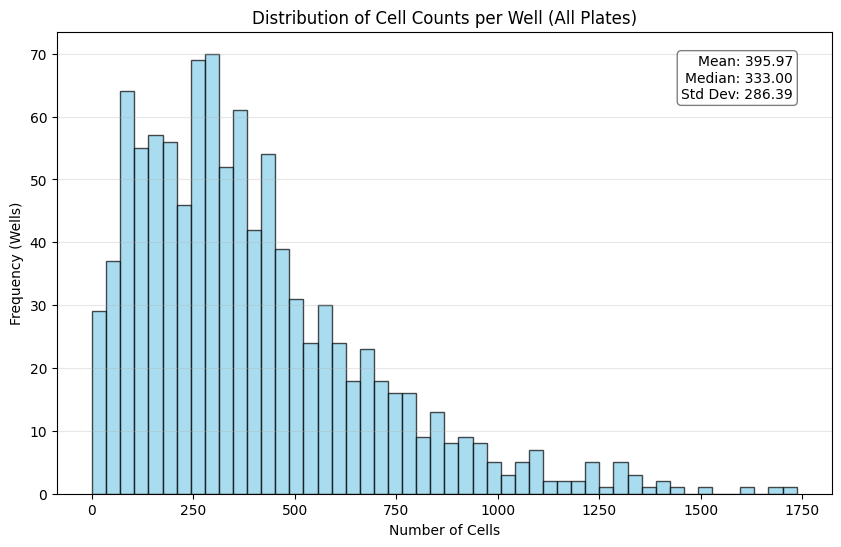

Median data saved to: E:\Thesis3april\files\aggregated_wells_median.csv
Std Dev data saved to: E:\Thesis3april\files\aggregated_wells_std.csv


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 1. SETUP & PATHS (MULTI-PLATE)
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'
PLATES = ["PLATE1_T0","PLATE1_T1","PLATE1_T2","PLATE2_T0","PLATE2_T1","PLATE2_T2",
          "PLATE3_T0","PLATE3_T1","PLATE3_T2","PLATE4_T0","PLATE4_T1","PLATE4_T2",
          "PLATE5_T0","PLATE5_T1","PLATE5_T2"]

# Paths for the two separate outputs
OUTPUT_CSV_MEDIAN = os.path.join(PROJECT_ROOT,"files", "aggregated_wells_median.csv")
OUTPUT_CSV_STD = os.path.join(PROJECT_ROOT,"files", "aggregated_wells_std.csv")

CELL_COUNT_THRESHOLD = 0  
TREATMENT_COL = "Treatment"

all_plates_median = []
all_plates_std = []
all_cell_counts = [] 

for plate_id in PLATES:
    print(f"\n--- Processing {plate_id} ---")
    
    FEATURES_BASE = os.path.join(PROJECT_ROOT, "features", plate_id)
    METADATA_PATH = os.path.join(PROJECT_ROOT, "metadata", f"index_{plate_id}.csv")
    
    if not os.path.exists(METADATA_PATH):
        print(f"Skipping {plate_id}: Metadata not found.")
        continue

    meta = pd.read_csv(METADATA_PATH)
    well_storage = {}
    well_to_treatment = {}

    for i in tqdm(meta.index, desc=f"Loading {plate_id}"):
        well_id = f"{plate_id}_{meta.loc[i, 'Metadata_Well']}"
        treatment = str(meta.loc[i, TREATMENT_COL]).strip()
        
        filename = os.path.join(FEATURES_BASE, 
                                str(meta.loc[i, "Metadata_Well"]), 
                                f"{meta.loc[i, 'Metadata_Site']}.npz")
        
        if os.path.isfile(filename):
            try:
                with np.load(filename) as data:
                    cells = data["features"]
                    cells_f = cells[~np.isnan(cells).any(axis=1)]
                    
                    if len(cells_f) > 0:
                        if well_id not in well_storage:
                            well_storage[well_id] = []
                            well_to_treatment[well_id] = treatment
                        well_storage[well_id].append(cells_f)
            except:
                continue

    # --- AGGREGATION & THRESHOLDING STEP ---
    for well_id, feature_list in well_storage.items():
        all_cells_in_well = np.vstack(feature_list)
        well_cell_count = all_cells_in_well.shape[0]
        all_cell_counts.append(well_cell_count)

        if well_cell_count >= CELL_COUNT_THRESHOLD:
            # Calculate both Median and Std Dev
            well_median = np.median(all_cells_in_well, axis=0)
            well_std = np.std(all_cells_in_well, axis=0)
            
            base_info = {
                "Plate": plate_id, 
                "Well_ID": well_id, 
                "Treatment": well_to_treatment[well_id],
                "Cell_Count": well_cell_count
            }
            
            # Create rows for both dataframes
            row_median = base_info.copy()
            row_std = base_info.copy()
            
            for idx in range(len(well_median)):
                row_median[idx] = well_median[idx]
                row_std[idx] = well_std[idx]
                
            all_plates_median.append(row_median)
            all_plates_std.append(row_std)

# Convert to DataFrames
df_median = pd.DataFrame(all_plates_median)
df_std = pd.DataFrame(all_plates_std)

# Helper function to reorder
def reorder_cols(df):
    meta_cols = ["Plate", "Well_ID", "Treatment", "Cell_Count"]
    feat_cols = [c for c in df.columns if c not in meta_cols]
    return df[meta_cols + feat_cols]

df_median = reorder_cols(df_median)
df_std = reorder_cols(df_std)

print(f"\nAggregation complete.")

# ==========================================
# 2. VISUALIZATION: CELL COUNT HISTOGRAM
# ==========================================
counts = np.array(all_cell_counts)
c_mean = np.mean(counts)
c_median = np.median(counts)
c_std = np.std(counts)

plt.figure(figsize=(10, 6))
plt.hist(counts, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Create stats text string
stats_text = f'Mean: {c_mean:.2f}\nMedian: {c_median:.2f}\nStd Dev: {c_std:.2f}'
# Place text box in the plot
plt.gca().text(0.95, 0.95, stats_text, transform=plt.gca().transAxes, 
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.title('Distribution of Cell Counts per Well (All Plates)')
plt.xlabel('Number of Cells')
plt.ylabel('Frequency (Wells)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 3. SAVE TO CSVs
# ==========================================
df_median.to_csv(OUTPUT_CSV_MEDIAN, index=False)
df_std.to_csv(OUTPUT_CSV_STD, index=False)

print(f"Median data saved to: {OUTPUT_CSV_MEDIAN}")
print(f"Std Dev data saved to: {OUTPUT_CSV_STD}")

In [ ]:
#count patches

In [2]:
import numpy as np
import os
from tqdm import tqdm

PROJECT_ROOT = r'E:\Thesis3april'
PLATES = ["PLATE1_T0","PLATE1_T1","PLATE1_T2","PLATE2_T0","PLATE2_T1","PLATE2_T2",
          "PLATE3_T0","PLATE3_T1","PLATE3_T2","PLATE4_T0","PLATE4_T1","PLATE4_T2",
          "PLATE5_T0","PLATE5_T1","PLATE5_T2"]

total_patches = 0
total_files = 0

print("Calculating total patch count...")

for plate in PLATES:
    feature_path = os.path.join(PROJECT_ROOT, "features", plate)
    
    if not os.path.exists(feature_path):
        print(f"Skipping {plate}: Path not found.")
        continue
        
    # Walk through all well subfolders
    for root, dirs, files in os.walk(feature_path):
        for file in files:
            if file.endswith(".npz"):
                file_path = os.path.join(root, file)
                try:
                    with np.load(file_path) as data:
                        # 'features' is the standard key in DeepProfiler npz files
                        # We only need the shape[0] (number of rows/cells)
                        total_patches += data["features"].shape[0]
                        total_files += 1
                except Exception as e:
                    print(f"Could not read {file}: {e}")

print("\n--- Final Statistics ---")
print(f"Total .npz files (sites) processed: {total_files}")
print(f"Total number of patches (cells):     {total_patches:,}")

Calculating total patch count...

--- Final Statistics ---
Total .npz files (sites) processed: 17524
Total number of patches (cells):     406,266


In [ ]:
#remove mutants less than 5 patches

In [3]:
import pandas as pd
import os

# 1. SETUP
PROJECT_ROOT = r'E:\Thesis3april'
INPUT_CSV = os.path.join(PROJECT_ROOT, "files", "aggregated_wells_median.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "files")

# Create the directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. DEFINE YOUR NEW THRESHOLD
STRICT_THRESHOLD = 5 

# 3. LOAD & FILTER
print(f"Loading {INPUT_CSV}...")
df = pd.read_csv(INPUT_CSV)

# Identify the wells that ARE BELOW the threshold
removed_df = df[df['Cell_Count'] < STRICT_THRESHOLD].copy()

# Identify the wells that ARE ABOVE or EQUAL to the threshold
filtered_df = df[df['Cell_Count'] >= STRICT_THRESHOLD].copy()

# 4. REPORT & SAVE
print(f"\n--- Filtering Summary ---")
print(f"Original wells:       {len(df)}")
print(f"Wells kept:           {len(filtered_df)}")
print(f"Wells removed:        {len(removed_df)}")
print(f"-------------------------")

if not removed_df.empty:
    print(f"\n--- LIST OF REMOVED WELLS (Count < {STRICT_THRESHOLD}) ---")
    # We only show the metadata columns for the removed wells
    print(removed_df[['Plate', 'Well_ID', 'Treatment', 'Cell_Count']].to_string(index=False))
else:
    print("\nNo wells were below the threshold.")

# 5. SAVE DATA
OUTPUT_CSV_FILTERED = os.path.join(OUTPUT_DIR, f"aggregated_wells_median_min5.csv")
filtered_df.to_csv(OUTPUT_CSV_FILTERED, index=False)

print(f"\nDone! Filtered data saved to: {OUTPUT_CSV_FILTERED}")

Loading E:\Thesis3april\files\aggregated_wells_median.csv...

--- Filtering Summary ---
Original wells:       1026
Wells kept:           1023
Wells removed:        3
-------------------------

--- LIST OF REMOVED WELLS (Count < 5) ---
    Plate      Well_ID Treatment  Cell_Count
PLATE1_T1 PLATE1_T1_F4      mreC           1
PLATE1_T2 PLATE1_T2_A6      dapH           1
PLATE3_T0 PLATE3_T0_B7      xkdB           2

Done! Filtered data saved to: E:\Thesis3april\files\aggregated_wells_median_min5.csv


In [ ]:
#plot without feature selection

In [89]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# --- 0. ADAPTABLE STYLE PARAMETERS ---
# Axis Style
AXIS_LINE_WIDTH = 3       # Thickness of the L-shaped axis lines
AXIS_TICK_WIDTH = 3       # Thickness of the tick marks
AXIS_TICK_LEN = 8         # Length of the tick marks
AXIS_TICK_FONT_SIZE = 25  # Size of the numbers (0, 5, 10...) on the axis
AXIS_TITLE_FONT_SIZE = 25 # Size of "UMAP 1" and "UMAP 2" text

# Legend Style
LEGEND_FONT_SIZE = 25     # Font size for the legend text
LEGEND_SYMBOL_SIZE = 14   # Size of the symbols in the legend list
HEADER_SYMBOL_SIZE = 14   # Size of the Square/Circle symbols in the header

# Plot Marker Style
MARKER_SIZE = 8           # Size of the dots/squares in the actual plot
MARKER_OPACITY = 0.8      # Transparency of the points (0 to 1)

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", "aggregated_wells_median_min5.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "All_Plates_NofeatureSelection")
COORD_DIR = os.path.join(OUTPUT_DIR, "coordinates")

# Create directories
for d in [OUTPUT_DIR, COORD_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)


df = pd.read_csv(file_path)
df.columns = df.columns.astype(str)

# --- 2. SELECTION & MAPPING ---
SELECTED_PLATES = ["PLATE1_T0","PLATE1_T1","PLATE1_T2","PLATE2_T0","PLATE2_T1","PLATE2_T2",
                   "PLATE3_T0","PLATE3_T1","PLATE3_T2","PLATE4_T0","PLATE4_T1","PLATE4_T2",
                   "PLATE5_T0","PLATE5_T1","PLATE5_T2"]

if SELECTED_PLATES:
    df = df[df['Plate'].isin(SELECTED_PLATES)].copy()

df['Type'] = df['Treatment'].apply(lambda x: 'Control' if x.lower() in ["no_sgrna", "nosgrna"] else 'Mutant')

time_map = {"T0": "no-xyl", "T1": "xyl5", "T2": "xyl12"}
unique_plates = sorted(df['Plate'].unique())
plate_rename_map = {}
for p in unique_plates:
    new_name = p.replace("PLATE", "P")
    for t_old, t_new in time_map.items():
        if t_old in new_name:
            new_name = new_name.replace(t_old, t_new)
    plate_rename_map[p] = new_name

df['Plate_Display'] = df['Plate'].map(plate_rename_map)

custom_colors = [
    '#5DADE2', '#D988B9', '#52BE80', '#E74C3C', '#AF7AC5', 
    '#707B7C', '#B7950B', '#8E44AD', '#E59896', '#5D3FD3', 
    '#45B39D', '#F333FF', '#FF3385', '#C39BD3', '#7D6608'
]

# --- 3. DEFINE CHANNELS ---
vetted_features = [c for c in df.columns if c.isdigit()]

def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All Vetted Channels", "indices": vetted_features},
    {"name": "Channel 1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel 2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel 3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel 4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel 5", "indices": get_channel_features(5120, 6400)}
]

# --- 4. RUN UMAP LOOP ---
for config in plot_configs:
    valid_indices = [idx for idx in config['indices'] if idx in df.columns]
    if not valid_indices: continue
    
    print(f"Processing: {config['name']} ({len(valid_indices)} features)...")
    
    X_scaled = StandardScaler().fit_transform(df[valid_indices].values)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    # Save coordinates
    meta_cols = ['Plate', 'Plate_Display', 'Well_ID', 'Treatment', 'Type', 'Cell_Count']
    available_meta = [c for c in meta_cols if c in df.columns]
    df_coords = df[available_meta].copy()
    df_coords['UMAP1'], df_coords['UMAP2'] = embedding[:, 0], embedding[:, 1]
    df_coords.to_csv(os.path.join(COORD_DIR, f"Coords_{config['name'].replace(' ', '_')}.csv"), index=False)

    # --- CREATE PLOT ---
    fig = go.Figure()

    # Legend Header
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no-sgRNA', showlegend=True
    ))
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True
    ))

    # Data Traces
    conditions = sorted(df_coords['Plate_Display'].unique())
    for i, condition in enumerate(conditions):
        cond_data = df_coords[df_coords['Plate_Display'] == condition]
        color = custom_colors[i % len(custom_colors)]
        
        for t_type in ['Mutant', 'Control']:
            sub_data = cond_data[cond_data['Type'] == t_type]
            if sub_data.empty: continue
            
            fig.add_trace(go.Scatter(
                x=sub_data['UMAP1'], y=sub_data['UMAP2'],
                mode='markers', name=condition,
                showlegend=(t_type == 'Mutant'), 
                legendgroup=condition,
                marker=dict(
                    symbol='circle' if t_type == 'Mutant' else 'square',
                    size=MARKER_SIZE, color=color, opacity=MARKER_OPACITY,
                    line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0)
                ),
                text=sub_data['Treatment'], hoverinfo='text+name'
            ))

    # Layout
    fig.update_layout(
        width=900, height=900, template='plotly_white',
        font=dict(family='Arial'),
        
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE)
        ),
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE), 
          
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE) 
            
        ),
        
    )

    # Save
    base_name = f"UMAP_{config['name'].replace(' ', '_')}"
    fig.write_html(os.path.join(OUTPUT_DIR, f"{base_name}.html"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.png"), scale=7)
    
    print(f"Finished {config['name']}")

Processing: All Vetted Channels (6400 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished All Vetted Channels
Processing: Channel 1 (1280 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 1
Processing: Channel 2 (1280 features)...


...

Finished Channel 3
Processing: Channel 4 (1280 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 4
Processing: Channel 5 (1280 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 5


In [ ]:
#time overlay on everything without feature selection

In [93]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3
AXIS_TICK_WIDTH = 3
AXIS_TICK_LEN = 8
AXIS_TICK_FONT_SIZE = 24
AXIS_TITLE_FONT_SIZE = 24

LEGEND_FONT_SIZE = 24
LEGEND_SYMBOL_SIZE = 14
HEADER_SYMBOL_SIZE = 14

MARKER_SIZE = 8
MARKER_OPACITY = 0.8

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", "aggregated_wells_median_min5.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "AllPlates_noSelection_Time_Overlay")
COORD_DIR = os.path.join(OUTPUT_DIR, "coordinates")

for folder in [OUTPUT_DIR, COORD_DIR]:
    if not os.path.exists(folder):
        os.makedirs(folder)

df = pd.read_csv(file_path)
df.columns = df.columns.astype(str)

# --- 2. PREPROCESSING & MAPPING ---
df['Timepoint'] = df['Plate'].str.extract(r'(T\d+)')
time_display_map = {'T0': 'no-xyl', 'T1': 'xyl5', 'T2': 'xyl12'}
df['Time_Display'] = df['Timepoint'].map(time_display_map)
df['Type'] = df['Treatment'].apply(lambda x: 'Control' if str(x).lower() in ["no_sgrna", "nosgrna"] else 'Mutant')

# Updated Color Mapping with Mutant/Control differences
time_colors = {
    'no-xyl': {'Mutant': '#FFA07A', 'Control': "#B13E17"}, # Light Salmon vs Darker Coral
    'xyl5':   {'Mutant': '#4DB6AC', 'Control': "#036257"}, # Light Teal vs Deep Teal
    'xyl12':  {'Mutant': '#F0D05D', 'Control': '#B8860B'}  # Light Goldenrod vs Dark Goldenrod
}

# --- 3. CHANNEL SELECTION ---
vetted_features = [c for c in df.columns if c.isdigit()]
def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All Vetted Channels", "indices": vetted_features},
    {"name": "Channel 1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel 2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel 3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel 4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel 5", "indices": get_channel_features(5120, 6400)}
]

# --- 4. RUN UMAP LOOP ---
for config in plot_configs:
    valid_indices = [idx for idx in config['indices'] if idx in df.columns]
    if not valid_indices: continue
    
    print(f"Generating Time Overlay for: {config['name']}...")
    
    X_scaled = StandardScaler().fit_transform(df[valid_indices].values)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    df_plot = df[['Plate', 'Well_ID', 'Treatment', 'Type', 'Time_Display']].copy()
    df_plot['UMAP1'], df_plot['UMAP2'] = embedding[:, 0], embedding[:, 1]

    coord_file = f"Coords_Time_{config['name'].replace(' ', '_')}.csv"
    df_plot.to_csv(os.path.join(COORD_DIR, coord_file), index=False)

    fig = go.Figure()

    # A) Add Legend Header
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no-sgRNA', showlegend=True
    ))
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True
    ))

    # B) Add Data Traces grouped by Time
    times = ['no-xyl', 'xyl5', 'xyl12']
    for t_val in times:
        for t_type in ['Mutant', 'Control']:
            mask = (df_plot['Time_Display'] == t_val) & (df_plot['Type'] == t_type)
            curr = df_plot[mask]
            if curr.empty: continue
            
            # Access nested color based on Type
            color = time_colors[t_val][t_type]
            
            fig.add_trace(go.Scatter(
                x=curr['UMAP1'], y=curr['UMAP2'], mode='markers',
                name=t_val,
                legendgroup=t_val,
                showlegend=True if t_type == 'Mutant' else False,
                marker=dict(
                    color=color, 
                    size=MARKER_SIZE,
                    symbol='circle' if t_type == 'Mutant' else 'square',
                    line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0),
                    opacity=MARKER_OPACITY
                ),
                text=curr['Treatment'],
                hoverinfo='text+name'
            ))

    # C) Final Layout
    fig.update_layout(
        width=900, height=900,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE)
        ),
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE)
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE)
        )
    )

    base_name = f"UMAP_Time_{config['name'].replace(' ', '_')}"
    fig.write_html(os.path.join(OUTPUT_DIR, f"{base_name}.html"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.png"), scale=7)

print("\nDone. Time overlay plots and coordinates are saved.")

Generating Time Overlay for: All Vetted Channels...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Generating Time Overlay for: Channel 1...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Generating Time Overlay for: Channel 2...


...

Generating Time Overlay for: Channel 4...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Generating Time Overlay for: Channel 5...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Done. Time overlay plots and coordinates are saved.


In [ ]:
#feature seleciton on everything 

In [52]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 0. GLOBAL SETUP
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'
INPUT_CSV = os.path.join(PROJECT_ROOT, "files", "aggregated_wells_median_min5.csv") 
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "files")
CONTROL_LABEL = "no_sgRNA" 

print("Loading raw data...")
df_raw = pd.read_csv(INPUT_CSV)
df_raw.columns = [str(c) for c in df_raw.columns]

# Separate Metadata and Features
metadata_cols = ['Plate', 'Well_ID', 'Treatment', 'Cell_Count']
feature_cols = [c for c in df_raw.columns if c not in metadata_cols]

# Helper function to display control counts
def print_control_summary(df, step_name):
    controls = df[df['Treatment'] == CONTROL_LABEL]
    count = len(controls)
    print(f"[{step_name}] Controls remaining: {count}")
    # Optional: Breakdown by plate
    # print(controls.groupby('Plate').size())

# ==========================================
# TOOLBOX: FUNCTIONS
# ==========================================

def filter_within_plate_consistency(df, features, top_n_to_keep=2000):
    ctrls = df[df['Treatment'] == CONTROL_LABEL]
    within_plate_variation = ctrls.groupby('Plate')[features].std().mean()
    consistent_features = within_plate_variation.sort_values(ascending=True).head(top_n_to_keep).index.tolist()
    return consistent_features

def filter_across_plate_stability(df, features, top_n_to_keep=200):
    ctrls = df[df['Treatment'] == CONTROL_LABEL]
    plate_medians = ctrls.groupby('Plate')[features].median()

    tp_batch_noises = []
    for tp in ['T0', 'T1', 'T2']:
        tp_plates = [p for p in plate_medians.index if p.endswith(tp)]
        if len(tp_plates) > 1:
            noise = plate_medians.loc[tp_plates].std()
            tp_batch_noises.append(noise)
    
    if not tp_batch_noises:
        return features 
        
    total_batch_noise = pd.concat(tp_batch_noises, axis=1).mean(axis=1)
    stable_features = total_batch_noise.sort_values(ascending=True).head(top_n_to_keep).index.tolist()
    return stable_features

def filter_redundancy(df, features, correlation_threshold=0.9):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]
    final_features = [f for f in features if f not in to_drop]
    return final_features

# ==========================================
# EXECUTION PIPELINE
# ==========================================

print(f"Total starting features: {len(feature_cols)}")
print_control_summary(df_raw, "Initial")

# --- STEP 0: GLOBAL VARIANCE FILTER ---
print(f"\nRunning Step 0: Global Variance Filter (std > 0.01)...")
initial_std = df_raw[feature_cols].std()
active_features = initial_std[initial_std > 0.01].index.tolist()
removed_0 = len(feature_cols) - len(active_features)
print(f"-> Removed: {removed_0} | Remaining: {len(active_features)}")

# --- STEP 1: WITHIN-PLATE CONSISTENCY ---
print(f"\nRunning Step 1: Within-Plate Consistency (Top 2000)...")
step1_features = filter_within_plate_consistency(df_raw, active_features, top_n_to_keep=2000)
removed_1 = len(active_features) - len(step1_features)
print(f"-> Removed: {removed_1} | Remaining: {len(step1_features)}")
print_control_summary(df_raw, "Step 1")

# --- STEP 2: ACROSS-PLATE STABILITY ---
print(f"\nRunning Step 2: Across-Plate Stability (Top 200)...")
step2_features = filter_across_plate_stability(df_raw, step1_features, top_n_to_keep=200)
removed_2 = len(step1_features) - len(step2_features)
print(f"-> Removed: {removed_2} | Remaining: {len(step2_features)}")
print_control_summary(df_raw, "Step 2")

# --- STEP 3: REDUNDANCY REMOVAL ---
print(f"\nRunning Step 3: Redundancy Filter (Threshold 0.9)...")
final_feature_list = filter_redundancy(df_raw, step2_features, correlation_threshold=0.9)
removed_3 = len(step2_features) - len(final_feature_list)
print(f"-> Removed: {removed_3} | Remaining: {len(final_feature_list)}")
print_control_summary(df_raw, "Step 3")

# ==========================================
# FINAL SAVE
# ==========================================
df_final = df_raw[metadata_cols + final_feature_list]
output_path = os.path.join(OUTPUT_DIR, "vettedcellcounts.csv")
df_final.to_csv(output_path, index=False)

print("\n" + "="*40)
print(f"WORKFLOW COMPLETE")
print(f"Total features filtered out: {len(feature_cols) - len(final_feature_list)}")
print(f"Final feature count: {len(final_feature_list)}")
print(f"Saved to: {output_path}")
print("="*40)

Loading raw data...
Total starting features: 6400
[Initial] Controls remaining: 131

Running Step 0: Global Variance Filter (std > 0.01)...
-> Removed: 944 | Remaining: 5456

Running Step 1: Within-Plate Consistency (Top 2000)...
-> Removed: 3456 | Remaining: 2000
[Step 1] Controls remaining: 131

Running Step 2: Across-Plate Stability (Top 200)...
-> Removed: 1800 | Remaining: 200
[Step 2] Controls remaining: 131

Running Step 3: Redundancy Filter (Threshold 0.9)...
-> Removed: 5 | Remaining: 195
[Step 3] Controls remaining: 131

WORKFLOW COMPLETE
Total features filtered out: 6205
Final feature count: 195
Saved to: E:\Thesis3april\files\vettedcellcounts.csv


In [ ]:
#aantal controles

In [54]:
# Assuming 'df_final' is your final dataframe after all filtering
# and 'CONTROL_LABEL' is "no_sgRNA"

def summarize_final_controls(df, control_label):
    # Filter for controls only
    controls_df = df[df['Treatment'] == control_label].copy()
    
    # Create a Timepoint column based on the Plate name
    # This looks for T0, T1, or T2 within the Plate string
    controls_df['Timepoint'] = controls_df['Plate'].str.extract(r'(T[0-2])')
    
    # Count occurrences
    counts = controls_df.groupby('Timepoint').size()
    
    print("--- Final Control Counts per Condition ---")
    if counts.empty:
        print("No controls found. Check if CONTROL_LABEL matches your data.")
    else:
        print(counts)
    
    return counts

# Run it
summarize_final_controls(df_final, CONTROL_LABEL)

--- Final Control Counts per Condition ---
Timepoint
T0    43
T1    46
T2    42
dtype: int64


Timepoint
T0    43
T1    46
T2    42
dtype: int64

In [ ]:
#Plotting all after featue seleciton

In [5]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# --- 0. ADAPTABLE STYLE PARAMETERS ---
# Axis Style
AXIS_LINE_WIDTH = 3       # Thickness of the L-shaped axis lines
AXIS_TICK_WIDTH = 3       # Thickness of the tick marks
AXIS_TICK_LEN = 8         # Length of the tick marks
AXIS_TICK_FONT_SIZE = 24  # Size of the numbers (0, 5, 10...) on the axis
AXIS_TITLE_FONT_SIZE = 24 # Size of "UMAP 1" and "UMAP 2" text

# Legend Style
LEGEND_FONT_SIZE = 24     # Font size for the legend text
LEGEND_SYMBOL_SIZE = 14   # Size of the symbols in the legend list
HEADER_SYMBOL_SIZE = 14   # Size of the Square/Circle symbols in the header

# Plot Marker Style
MARKER_SIZE = 8           # Size of the dots/squares in the actual plot
MARKER_OPACITY = 0.8      # Transparency of the points (0 to 1)

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", "vettedcellcounts.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "All_Plates_featureSelection")
COORD_DIR = os.path.join(OUTPUT_DIR, "coordinates")

for d in [OUTPUT_DIR, COORD_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

df = pd.read_csv(file_path)
df.columns = df.columns.astype(str)

# --- 2. SELECTION & MAPPING ---
SELECTED_PLATES = ["PLATE1_T0","PLATE1_T1","PLATE1_T2","PLATE2_T0","PLATE2_T1","PLATE2_T2",
                   "PLATE3_T0","PLATE3_T1","PLATE3_T2","PLATE4_T0","PLATE4_T1","PLATE4_T2",
                   "PLATE5_T0","PLATE5_T1","PLATE5_T2"]

if SELECTED_PLATES:
    df = df[df['Plate'].isin(SELECTED_PLATES)].copy()

df['Type'] = df['Treatment'].apply(lambda x: 'Control' if x.lower() in ["no_sgrna", "nosgrna"] else 'Mutant')

time_map = {"T0": "no-xyl", "T1": "xyl5", "T2": "xyl12"}
unique_plates = sorted(df['Plate'].unique())
plate_rename_map = {}
for p in unique_plates:
    new_name = p.replace("PLATE", "P")
    for t_old, t_new in time_map.items():
        if t_old in new_name:
            new_name = new_name.replace(t_old, t_new)
    plate_rename_map[p] = new_name

df['Plate_Display'] = df['Plate'].map(plate_rename_map)

custom_colors = [
    '#5DADE2', '#D988B9', '#52BE80', '#E74C3C', '#AF7AC5', 
    '#707B7C', '#B7950B', '#8E44AD', '#E59896', '#5D3FD3', 
    '#45B39D', '#F333FF', '#FF3385', '#C39BD3', '#7D6608'
]

# --- 3. DEFINE CHANNELS ---
vetted_features = [c for c in df.columns if c.isdigit()]

def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All Vetted Channels", "indices": vetted_features},
    {"name": "Channel 1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel 2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel 3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel 4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel 5", "indices": get_channel_features(5120, 6400)}
]

# --- 4. RUN UMAP LOOP ---
for config in plot_configs:
    valid_indices = [idx for idx in config['indices'] if idx in df.columns]
    if not valid_indices: continue
    
    print(f"Processing: {config['name']} ({len(valid_indices)} features)...")
    
    X_scaled = StandardScaler().fit_transform(df[valid_indices].values)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    # Save coordinates
    meta_cols = ['Plate', 'Plate_Display', 'Well_ID', 'Treatment', 'Type', 'Cell_Count']
    available_meta = [c for c in meta_cols if c in df.columns]
    df_coords = df[available_meta].copy()
    df_coords['UMAP1'], df_coords['UMAP2'] = embedding[:, 0], embedding[:, 1]
    df_coords.to_csv(os.path.join(COORD_DIR, f"Coords_{config['name'].replace(' ', '_')}.csv"), index=False)

    # --- CREATE PLOT ---
    fig = go.Figure()

    # Legend Header
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no-sgRNA', showlegend=True
    ))
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True
    ))

    # Data Traces
    conditions = sorted(df_coords['Plate_Display'].unique())
    for i, condition in enumerate(conditions):
        cond_data = df_coords[df_coords['Plate_Display'] == condition]
        color = custom_colors[i % len(custom_colors)]
        
        for t_type in ['Mutant', 'Control']:
            sub_data = cond_data[cond_data['Type'] == t_type]
            if sub_data.empty: continue
            
            fig.add_trace(go.Scatter(
                x=sub_data['UMAP1'], y=sub_data['UMAP2'],
                mode='markers', name=condition,
                showlegend=(t_type == 'Mutant'), 
                legendgroup=condition,
                marker=dict(
                    symbol='circle' if t_type == 'Mutant' else 'square',
                    size=MARKER_SIZE, color=color, opacity=MARKER_OPACITY,
                    line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0)
                ),
                text=sub_data['Treatment'], hoverinfo='text+name'
            ))

    # Layout
    fig.update_layout(
        width=900, height=900, template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE)
        ),
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE)
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE)
        )
    )

    # Save
    base_name = f"UMAP_{config['name'].replace(' ', '_')}"
    fig.write_html(os.path.join(OUTPUT_DIR, f"{base_name}.html"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.png"), scale=2)
    
    print(f"Finished {config['name']}")

Processing: All Vetted Channels (195 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished All Vetted Channels
Processing: Channel 1 (76 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 1
Processing: Channel 2 (16 features)...


...

Finished Channel 2
Processing: Channel 4 (72 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 4
Processing: Channel 5 (31 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 5


In [ ]:
#all met iets lichtere gedient maar mschn minder goed

In [ ]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.colors as mc
import colorsys

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8         
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 24     
LEGEND_SYMBOL_SIZE = 14   
HEADER_SYMBOL_SIZE = 14   

MARKER_SIZE = 8           
MARKER_OPACITY = 0.8      

# Helper function to lighten/darken colors
def adjust_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminance) by the amount.
    Input can be matplotlib color string, hex string, or RGB tuple.
    amount > 1.0 = lighter; amount < 1.0 = darker.
    """
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return mc.to_hex(colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2]))

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", "vettedcellcounts.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots", "All_Plates_featureSelection")
COORD_DIR = os.path.join(OUTPUT_DIR, "coordinates")

for d in [OUTPUT_DIR, COORD_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

df = pd.read_csv(file_path)
df.columns = df.columns.astype(str)

# --- 2. SELECTION & MAPPING ---
SELECTED_PLATES = ["PLATE1_T0","PLATE1_T1","PLATE1_T2","PLATE2_T0","PLATE2_T1","PLATE2_T2",
                   "PLATE3_T0","PLATE3_T1","PLATE3_T2","PLATE4_T0","PLATE4_T1","PLATE4_T2",
                   "PLATE5_T0","PLATE5_T1","PLATE5_T2"]

if SELECTED_PLATES:
    df = df[df['Plate'].isin(SELECTED_PLATES)].copy()

df['Type'] = df['Treatment'].apply(lambda x: 'Control' if x.lower() in ["no_sgrna", "nosgrna"] else 'Mutant')

time_map = {"T0": "no_xyl", "T1": "xyl5", "T2": "xyl12"}
unique_plates = sorted(df['Plate'].unique())
plate_rename_map = {}
for p in unique_plates:
    new_name = p.replace("PLATE", "P")
    for t_old, t_new in time_map.items():
        if t_old in new_name:
            new_name = new_name.replace(t_old, t_new)
    plate_rename_map[p] = new_name

df['Plate_Display'] = df['Plate'].map(plate_rename_map)

# Your base colors
custom_colors = [
    '#5DADE2', '#D988B9', '#52BE80', '#E74C3C', '#AF7AC5', 
    '#707B7C', '#B7950B', '#8E44AD', '#E59896', '#5D3FD3', 
    '#45B39D', '#F333FF', '#FF3385', '#C39BD3', '#7D6608'
]

# --- 3. DEFINE CHANNELS ---
vetted_features = [c for c in df.columns if c.isdigit()]
def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All Vetted Channels", "indices": vetted_features},
    {"name": "Channel 1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel 2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel 3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel 4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel 5", "indices": get_channel_features(5120, 6400)}
]

# --- 4. RUN UMAP LOOP ---
for config in plot_configs:
    valid_indices = [idx for idx in config['indices'] if idx in df.columns]
    if not valid_indices: continue
    
    print(f"Processing: {config['name']} ({len(valid_indices)} features)...")
    
    X_scaled = StandardScaler().fit_transform(df[valid_indices].values)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    df_coords = df[['Plate', 'Plate_Display', 'Well_ID', 'Treatment', 'Type', 'Cell_Count']].copy()
    df_coords['UMAP1'], df_coords['UMAP2'] = embedding[:, 0], embedding[:, 1]
    df_coords.to_csv(os.path.join(COORD_DIR, f"Coords_{config['name'].replace(' ', '_')}.csv"), index=False)

    fig = go.Figure()

    # Legend Header
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no_sgRNA', showlegend=True
    ))
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True
    ))

    # Data Traces
    conditions = sorted(df_coords['Plate_Display'].unique())
    for i, condition in enumerate(conditions):
        cond_data = df_coords[df_coords['Plate_Display'] == condition]
        base_color = custom_colors[i % len(custom_colors)]
        
        # Mutant = Lighter, Control = Darker
        mutant_color = adjust_color(base_color, amount=1.2) 
        control_color = adjust_color(base_color, amount=0.7) 
        
        for t_type in ['Mutant', 'Control']:
            sub_data = cond_data[cond_data['Type'] == t_type]
            if sub_data.empty: continue
            
            color = mutant_color if t_type == 'Mutant' else control_color
            
            fig.add_trace(go.Scatter(
                x=sub_data['UMAP1'], y=sub_data['UMAP2'],
                mode='markers', name=condition,
                showlegend=(t_type == 'Mutant'), 
                legendgroup=condition,
                marker=dict(
                    symbol='circle' if t_type == 'Mutant' else 'square',
                    size=MARKER_SIZE, color=color, opacity=MARKER_OPACITY,
                    line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0)
                ),
                text=sub_data['Treatment'], hoverinfo='text+name'
            ))

    fig.update_layout(
        width=900, height=900, template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(itemsizing='constant', font=dict(size=LEGEND_FONT_SIZE)),
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
           
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            
        )
    )

    base_name = f"UMAP_{config['name'].replace(' ', '_')}"
    fig.write_html(os.path.join(OUTPUT_DIR, f"{base_name}.html"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    # Updated to scale=7 for 500 DPI requirement
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.png"), scale=7)
    
    print(f"Finished {config['name']}")

Processing: All Vetted Channels (195 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished All Vetted Channels
Processing: Channel 1 (76 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 1
Processing: Channel 2 (16 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 2
Processing: Channel 4 (72 features)...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



KeyboardInterrupt: 

In [ ]:
#time overlay

In [92]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8         
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 24     
LEGEND_SYMBOL_SIZE = 14   
HEADER_SYMBOL_SIZE = 14   

MARKER_SIZE = 8           
MARKER_OPACITY = 0.8      

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", "vettedcellcounts.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "All_Plates_FeatureSelection_Time_Overlay")
COORD_DIR = os.path.join(OUTPUT_DIR, "coordinates")

for d in [OUTPUT_DIR, COORD_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

df = pd.read_csv(file_path)
df.columns = df.columns.astype(str)

# --- 2. PREPROCESSING & MAPPING ---
df['Timepoint'] = df['Plate'].str.extract(r'(T\d+)')
time_display_map = {'T0': 'no-xyl', 'T1': 'xyl5', 'T2': 'xyl12'}
df['Time_Display'] = df['Timepoint'].map(time_display_map)

df['Type'] = df['Treatment'].apply(lambda x: 'Control' if str(x).lower() in ["no_sgrna", "nosgrna"] else 'Mutant')

# Color Mapping: Sub-divided into Mutant (Lighter) and Control (Darker)
# Base Coral: #FF7F50 | Base Teal: #008080 | Base Goldenrod: #DAA520
time_colors = {
    'no-xyl': {'Mutant': '#FFA07A', 'Control': "#B13E17"}, # Light Salmon vs Darker Coral
    'xyl5':   {'Mutant': '#4DB6AC', 'Control': "#036257"}, # Light Teal vs Deep Teal
    'xyl12':  {'Mutant': '#F0D05D', 'Control': '#B8860B'}  # Light Goldenrod vs Dark Goldenrod
}

# --- 3. CHANNEL SELECTION ---
vetted_features = [c for c in df.columns if c.isdigit()]
def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All Vetted Channels", "indices": vetted_features},
    {"name": "Channel 1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel 2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel 3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel 4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel 5", "indices": get_channel_features(5120, 6400)}
]

# --- 4. RUN UMAP LOOP ---
for config in plot_configs:
    valid_indices = [idx for idx in config['indices'] if idx in df.columns]
    if not valid_indices: continue
    
    print(f"Generating Time Overlay for: {config['name']}...")
    
    X_scaled = StandardScaler().fit_transform(df[valid_indices].values)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    df_plot = df[['Plate', 'Well_ID', 'Treatment', 'Type', 'Time_Display']].copy()
    df_plot['UMAP1'], df_plot['UMAP2'] = embedding[:, 0], embedding[:, 1]

    coord_file = f"Coords_Time_{config['name'].replace(' ', '_')}.csv"
    df_plot.to_csv(os.path.join(COORD_DIR, coord_file), index=False)

    fig = go.Figure()

    # A) Legend Header
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no-sgRNA', showlegend=True
    ))
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True
    ))

    # B) Data Traces
    times = ['no-xyl', 'xyl5', 'xyl12']
    for t_val in times:
        for t_type in ['Mutant', 'Control']:
            mask = (df_plot['Time_Display'] == t_val) & (df_plot['Type'] == t_type)
            curr = df_plot[mask]
            if curr.empty: continue
            
            # Select the specific shade for this type
            color = time_colors[t_val][t_type]
            
            fig.add_trace(go.Scatter(
                x=curr['UMAP1'], y=curr['UMAP2'], mode='markers',
                name=t_val,
                legendgroup=t_val,
                showlegend=True if t_type == 'Mutant' else False,
                marker=dict(
                    color=color, 
                    size=MARKER_SIZE,
                    symbol='circle' if t_type == 'Mutant' else 'square',
                    # Controls have a black outline to make them pop even more
                    line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0),
                    opacity=MARKER_OPACITY
                ),
                text=curr['Treatment'],
                hovertemplate="<b>%{text}</b><br>Condition: %{name}<extra></extra>"
            ))

    # C) Final Layout
    fig.update_layout(
        width=900, height=900,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE)
        ),
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE)
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE)
        )
    )

    base_name = f"UMAP_Time_{config['name'].replace(' ', '_')}"
    fig.write_html(os.path.join(OUTPUT_DIR, f"{base_name}.html"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    # scale=7 ensures ~500 DPI for a 900x900 base image
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.png"), scale=7)

print("\nDone. 500 DPI PNGs, SVGs, and coordinates are saved.")

Generating Time Overlay for: All Vetted Channels...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Generating Time Overlay for: Channel 1...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Generating Time Overlay for: Channel 2...


...

Generating Time Overlay for: Channel 4...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Generating Time Overlay for: Channel 5...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Done. 500 DPI PNGs, SVGs, and coordinates are saved.


In [33]:

# 3.5 FEATURE SUMMARY PRINT-OUT
print("\n" + "="*45)
print(f"{'Channel Selection':<25} | {'Features Found':<15}")
print("-" * 45)
for config in plot_configs:
    print(f"{config['name']:<25} | {len(config['indices']):<15}")
print("="*45 + "\n")


Channel Selection         | Features Found 
---------------------------------------------
All Vetted Channels       | 195            
Channel 1                 | 76             
Channel 2                 | 16             
Channel 3                 | 0              
Channel 4                 | 72             
Channel 5                 | 31             



In [ ]:
#enkelT0enT1 bekijken
###
#

In [ ]:
#no xylose and xylose 5h plates without feature selection

In [ ]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.colors as mc
import colorsys

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3        
AXIS_TICK_WIDTH = 3        
AXIS_TICK_LEN = 8          
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 24     
LEGEND_SYMBOL_SIZE = 14   
HEADER_SYMBOL_SIZE = 14   

MARKER_SIZE = 8            
MARKER_OPACITY = 0.8      

# Helper function to lighten/darken colors
def adjust_color(color, amount=0.5):
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return mc.to_hex(colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2]))

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", "aggregated_wells_median_min5.csv")
# Updated folder name based on your second snippet
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_No_featureSelection")
COORD_DIR = os.path.join(OUTPUT_DIR, "coordinates")

for d in [OUTPUT_DIR, COORD_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

df = pd.read_csv(file_path)
df.columns = df.columns.astype(str)

SELECTED_PLATES = ["PLATE1_T0","PLATE1_T1","PLATE2_T0","PLATE2_T1","PLATE3_T0","PLATE3_T1",
                   "PLATE4_T0","PLATE4_T1","PLATE5_T0","PLATE5_T1"]

if SELECTED_PLATES:
    df = df[df['Plate'].isin(SELECTED_PLATES)].copy()

df['Type'] = df['Treatment'].apply(lambda x: 'Control' if x.lower() in ["no_sgrna", "nosgrna"] else 'Mutant')

time_map = {"T0": "no_xyl", "T1": "xyl5", "T2": "xyl10"}
unique_plates = sorted(df['Plate'].unique())
plate_rename_map = {}
for p in unique_plates:
    new_name = p.replace("PLATE", "P")
    for t_old, t_new in time_map.items():
        if t_old in new_name:
            new_name = new_name.replace(t_old, t_new)
    plate_rename_map[p] = new_name

df['Plate_Display'] = df['Plate'].map(plate_rename_map)

custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# --- 3. DEFINE CHANNELS ---
vetted_features = [c for c in df.columns if c.isdigit()]
def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All Vetted Channels", "indices": vetted_features},
    {"name": "Channel 1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel 2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel 3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel 4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel 5", "indices": get_channel_features(5120, 6400)}
]

# --- 4. RUN UMAP LOOP ---
for config in plot_configs:
    valid_indices = [idx for idx in config['indices'] if idx in df.columns]
    if not valid_indices: continue
    
    X_scaled = StandardScaler().fit_transform(df[valid_indices].values)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    df_coords = df[['Plate', 'Plate_Display', 'Well_ID', 'Treatment', 'Type', 'Cell_Count']].copy()
    df_coords['UMAP1'], df_coords['UMAP2'] = embedding[:, 0], embedding[:, 1]

    # --- SAVE COORDINATES ---
    base_name = f"UMAP_{config['name'].replace(' ', '_')}"
    df_coords.to_csv(os.path.join(COORD_DIR, f"{base_name}_coords.csv"), index=False)

    fig = go.Figure()

    # --- UPDATED LEGEND HEADERS ---
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no-sgRNA', showlegend=True))
    
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True))

    conditions = sorted(df_coords['Plate_Display'].unique())
    for i, condition in enumerate(conditions):
        cond_data = df_coords[df_coords['Plate_Display'] == condition]
        base_color = custom_colors[i % len(custom_colors)]
        mutant_color = adjust_color(base_color, amount=1.2) 
        control_color = adjust_color(base_color, amount=0.7) 
        
        for t_type in ['Mutant', 'Control']:
            sub_data = cond_data[cond_data['Type'] == t_type]
            if sub_data.empty: continue
            color = mutant_color if t_type == 'Mutant' else control_color
            fig.add_trace(go.Scatter(
                x=sub_data['UMAP1'], y=sub_data['UMAP2'],
                mode='markers', name=condition,
                showlegend=(t_type == 'Mutant'), 
                legendgroup=condition,
                marker=dict(symbol='circle' if t_type == 'Mutant' else 'square',
                            size=MARKER_SIZE, color=color, opacity=MARKER_OPACITY,
                            line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0)),
                text=sub_data['Treatment'], hoverinfo='text+name'))

    # --- UPDATED LAYOUT FOR CONSISTENT SQUARE PLOT AREA ---
    # Layout
    fig.update_layout(
        width=1200, height=900, template='plotly_white',                      # met de scalanchor en scale ratio forceer je x en y as tick scale gelijk, maar plot is breeder dan hoog, als je dus square forceert (900 x 900) dan is er veel witruimte
        font=dict(family='Arial'),
        
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE)
        ),
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE), 
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
          
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
            
        ),
        
    )

    fig.write_html(os.path.join(OUTPUT_DIR, f"{base_name}.html"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.png"), scale=7)
    
    print(f"Finished {config['name']}")

print("\nDone. Plots and coordinates generated successfully.")

c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished All Vetted Channels


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 1


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



...

Finished Channel 3


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 4


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 5

Done. Plots and coordinates generated successfully.


In [ ]:
#time ovarlay no xylose and xylose 5h without feature selection

In [13]:
import pandas as pd
import os
import plotly.graph_objects as go

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8         
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 24     
LEGEND_SYMBOL_SIZE = 14   
HEADER_SYMBOL_SIZE = 14   

MARKER_SIZE = 8           
MARKER_OPACITY = 0.8      

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_No_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_No_featureSelection_Time_Overlay")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Color Mapping for Timepoints
time_colors = {
    'no_xyl': {'Mutant': '#FFA07A', 'Control':  "#B13E17"}, 
    'xyl5':   {'Mutant': '#4DB6AC', 'Control': "#036257"}, 
}


# List the coordinate files you want to process
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 2. LOOP THROUGH EXISTING COORDINATES ---
for file_name in coord_files:
    print(f"Plotting Time Overlay from: {file_name}...")
    
    # Load existing coordinates
    df_plot = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Ensure Time_Display is available (mapping if needed)
    if 'Time_Display' not in df_plot.columns:
        df_plot['Timepoint'] = df_plot['Plate'].str.extract(r'(T\d+)')
        time_display_map = {'T0': 'no_xyl', 'T1': 'xyl5', 'T2': 'xyl10'}
        df_plot['Time_Display'] = df_plot['Timepoint'].map(time_display_map)

    fig = go.Figure()

    # A) Legend Header
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no_sgRNA', showlegend=True
    ))
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True
    ))

    # B) Data Traces
    times = ['no_xyl', 'xyl5', 'xyl10']
    for t_val in times:
        for t_type in ['Mutant', 'Control']:
            mask = (df_plot['Time_Display'] == t_val) & (df_plot['Type'] == t_type)
            curr = df_plot[mask]
            if curr.empty: continue
            
            color = time_colors.get(t_val, {}).get(t_type, '#CCCCCC') # Default gray if time not in map
            
            fig.add_trace(go.Scatter(
                x=curr['UMAP1'], y=curr['UMAP2'], mode='markers',
                name=t_val,
                legendgroup=t_val,
                showlegend=True if t_type == 'Mutant' else False,
                marker=dict(
                    color=color, 
                    size=MARKER_SIZE,
                    symbol='circle' if t_type == 'Mutant' else 'square',
                    line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0),
                    opacity=MARKER_OPACITY
                ),
                text=curr['Treatment'],
                hovertemplate="<b>%{text}</b><br>Condition: %{name}<extra></extra>"
            ))

    # C) Final Layout (Consistent Square Plot Area)
    fig.update_layout(
        width=1200, height=900, template='plotly_white',                      # met de scalanchor en scale ratio forceer je x en y as tick scale gelijk, maar plot is breeder dan hoog, als je dus square forceert (900 x 900) dan is er veel witruimte
        font=dict(family='Arial'),
        
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE)
        ),
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE), 
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
          
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
            
        ),
        
    )

    base_name = file_name.replace("Coords_", "UMAP_Time_")
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=7)
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print("\nDone. Time overlay plots generated with fixed square axes.")

Plotting Time Overlay from: UMAP_All_Vetted_Channels_coords.csv...
Plotting Time Overlay from: UMAP_Channel_1_coords.csv...
Plotting Time Overlay from: UMAP_Channel_2_coords.csv...
Plotting Time Overlay from: UMAP_Channel_3_coords.csv...
Plotting Time Overlay from: UMAP_Channel_4_coords.csv...
Plotting Time Overlay from: UMAP_Channel_5_coords.csv...

Done. Time overlay plots generated with fixed square axes.


In [ ]:
#preselection T0 en T1 enkel 

In [55]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 0. GLOBAL SETUP
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'
INPUT_CSV = os.path.join(PROJECT_ROOT, "files", "aggregated_wells_median_min5.csv") 
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "files")
CONTROL_LABEL = "no_sgRNA" 

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print("Loading raw data...")
df_raw_full = pd.read_csv(INPUT_CSV)
df_raw_full.columns = [str(c) for c in df_raw_full.columns]

# --- NEW STEP: FILTER OUT T2 AND SAVE COPY ---
print("Filtering out T2 samples...")
df_raw = df_raw_full[df_raw_full['Plate'].str.contains('T0|T1')].copy()

filtered_raw_path = os.path.join(OUTPUT_DIR, "raw_data_T0_T1_only.csv")
df_raw.to_csv(filtered_raw_path, index=False)

# Separate Metadata and Features
metadata_cols = ['Plate', 'Well_ID', 'Treatment', 'Cell_Count']
feature_cols = [c for c in df_raw.columns if c not in metadata_cols]

# ==========================================
# TOOLBOX: FUNCTIONS
# ==========================================

def filter_within_plate_consistency(df, features, top_n_to_keep=2000):
    ctrls = df[df['Treatment'] == CONTROL_LABEL]
    within_plate_variation = ctrls.groupby('Plate')[features].std().mean()
    consistent_features = within_plate_variation.sort_values(ascending=True).head(top_n_to_keep).index.tolist()
    return consistent_features

def filter_across_plate_stability(df, features, top_n_to_keep=200):
    ctrls = df[df['Treatment'] == CONTROL_LABEL]
    plate_medians = ctrls.groupby('Plate')[features].median()

    tp_batch_noises = []
    for tp in ['T0', 'T1']:
        tp_plates = [p for p in plate_medians.index if p.endswith(tp)]
        if len(tp_plates) > 1:
            noise = plate_medians.loc[tp_plates].std()
            tp_batch_noises.append(noise)
    
    if not tp_batch_noises:
        return features 
        
    total_batch_noise = pd.concat(tp_batch_noises, axis=1).mean(axis=1)
    stable_features = total_batch_noise.sort_values(ascending=True).head(top_n_to_keep).index.tolist()
    return stable_features

def filter_redundancy(df, features, correlation_threshold=0.9):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]
    final_features = [f for f in features if f not in to_drop]
    return final_features

# ==========================================
# EXECUTION PIPELINE
# ==========================================

print(f"\nInitial total features: {len(feature_cols)}")

# --- STEP 0: GLOBAL VARIANCE FILTER ---
print(f"\nRunning Step 0: Global Variance Filter (std > 0.01)...")
initial_std = df_raw[feature_cols].std()
active_features = initial_std[initial_std > 0.01].index.tolist()
removed_0 = len(feature_cols) - len(active_features)
print(f"-> Removed: {removed_0} | Remaining: {len(active_features)}")

# --- STEP 1: WITHIN-PLATE CONSISTENCY ---
print(f"\nRunning Step 1: Within-Plate Consistency (Top 2000)...")
step1_features = filter_within_plate_consistency(df_raw, active_features, top_n_to_keep=2000)
removed_1 = len(active_features) - len(step1_features)
print(f"-> Removed: {removed_1} | Remaining: {len(step1_features)}")

# --- STEP 2: ACROSS-PLATE STABILITY ---
print(f"\nRunning Step 2: Across-Plate Stability (Top 200)...")
step2_features = filter_across_plate_stability(df_raw, step1_features, top_n_to_keep=200)
removed_2 = len(step1_features) - len(step2_features)
print(f"-> Removed: {removed_2} | Remaining: {len(step2_features)}")

# --- STEP 3: REDUNDANCY REMOVAL ---
print(f"\nRunning Step 3: Redundancy Filter (Threshold 0.9)...")
final_feature_list = filter_redundancy(df_raw, step2_features, correlation_threshold=0.9)
removed_3 = len(step2_features) - len(final_feature_list)
print(f"-> Removed: {removed_3} | Remaining: {len(final_feature_list)}")

# ==========================================
# FINAL SAVE & SUMMARY
# ==========================================
df_final = df_raw[metadata_cols + final_feature_list]
output_path = os.path.join(OUTPUT_DIR, "vettedcellcounts_T0_T1.csv")
df_final.to_csv(output_path, index=False)

# Get control counts per timepoint for the final file
final_controls = df_final[df_final['Treatment'] == CONTROL_LABEL].copy()
final_controls['Timepoint'] = final_controls['Plate'].str.extract(r'(T[0-1])')
control_counts = final_controls.groupby('Timepoint').size()

print("\n" + "="*40)
print(f"WORKFLOW COMPLETE (T0 & T1 ONLY)")
print(f"Total features removed: {len(feature_cols) - len(final_feature_list)}")
print(f"Final feature count: {len(final_feature_list)}")
print("\n--- Final Control Counts per Condition ---")
print(control_counts if not control_counts.empty else "No controls found.")
print("="*40)

Loading raw data...
Filtering out T2 samples...

Initial total features: 6400

Running Step 0: Global Variance Filter (std > 0.01)...
-> Removed: 1354 | Remaining: 5046

Running Step 1: Within-Plate Consistency (Top 2000)...
-> Removed: 3046 | Remaining: 2000

Running Step 2: Across-Plate Stability (Top 200)...
-> Removed: 1800 | Remaining: 200

Running Step 3: Redundancy Filter (Threshold 0.9)...
-> Removed: 9 | Remaining: 191

WORKFLOW COMPLETE (T0 & T1 ONLY)
Total features removed: 6209
Final feature count: 191

--- Final Control Counts per Condition ---
Timepoint
T0    43
T1    46
dtype: int64


In [ ]:
#plot enkel T0 en T1

In [9]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.colors as mc
import colorsys

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3        
AXIS_TICK_WIDTH = 3        
AXIS_TICK_LEN = 8          
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 24     
LEGEND_SYMBOL_SIZE = 14   
HEADER_SYMBOL_SIZE = 14   

MARKER_SIZE = 8            
MARKER_OPACITY = 0.8      

# Helper function to lighten/darken colors
def adjust_color(color, amount=0.5):
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return mc.to_hex(colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2]))

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", "vettedcellcounts_T0_T1.csv")
# Updated folder name based on your second snippet
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection")
COORD_DIR = os.path.join(OUTPUT_DIR, "coordinates")

for d in [OUTPUT_DIR, COORD_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

df = pd.read_csv(file_path)
df.columns = df.columns.astype(str)

SELECTED_PLATES = ["PLATE1_T0","PLATE1_T1","PLATE2_T0","PLATE2_T1","PLATE3_T0","PLATE3_T1",
                   "PLATE4_T0","PLATE4_T1","PLATE5_T0","PLATE5_T1"]

if SELECTED_PLATES:
    df = df[df['Plate'].isin(SELECTED_PLATES)].copy()

df['Type'] = df['Treatment'].apply(lambda x: 'Control' if x.lower() in ["no_sgrna", "nosgrna"] else 'Mutant')

time_map = {"T0": "no_xyl", "T1": "xyl5", "T2": "xyl10"}
unique_plates = sorted(df['Plate'].unique())
plate_rename_map = {}
for p in unique_plates:
    new_name = p.replace("PLATE", "P")
    for t_old, t_new in time_map.items():
        if t_old in new_name:
            new_name = new_name.replace(t_old, t_new)
    plate_rename_map[p] = new_name

df['Plate_Display'] = df['Plate'].map(plate_rename_map)

custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# --- 3. DEFINE CHANNELS ---
vetted_features = [c for c in df.columns if c.isdigit()]
def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All Vetted Channels", "indices": vetted_features},
    {"name": "Channel 1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel 2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel 3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel 4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel 5", "indices": get_channel_features(5120, 6400)}
]

# --- 4. RUN UMAP LOOP ---
for config in plot_configs:
    valid_indices = [idx for idx in config['indices'] if idx in df.columns]
    if not valid_indices: continue
    
    X_scaled = StandardScaler().fit_transform(df[valid_indices].values)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    
    df_coords = df[['Plate', 'Plate_Display', 'Well_ID', 'Treatment', 'Type', 'Cell_Count']].copy()
    df_coords['UMAP1'], df_coords['UMAP2'] = embedding[:, 0], embedding[:, 1]

    # --- SAVE COORDINATES ---
    base_name = f"UMAP_{config['name'].replace(' ', '_')}"
    df_coords.to_csv(os.path.join(COORD_DIR, f"{base_name}_coords.csv"), index=False)

    fig = go.Figure()

    # --- UPDATED LEGEND HEADERS ---
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no-sgRNA', showlegend=True))
    
    fig.add_trace(go.Scatter(x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True))

    conditions = sorted(df_coords['Plate_Display'].unique())
    for i, condition in enumerate(conditions):
        cond_data = df_coords[df_coords['Plate_Display'] == condition]
        base_color = custom_colors[i % len(custom_colors)]
        mutant_color = adjust_color(base_color, amount=1.2) 
        control_color = adjust_color(base_color, amount=0.7) 
        
        for t_type in ['Mutant', 'Control']:
            sub_data = cond_data[cond_data['Type'] == t_type]
            if sub_data.empty: continue
            color = mutant_color if t_type == 'Mutant' else control_color
            fig.add_trace(go.Scatter(
                x=sub_data['UMAP1'], y=sub_data['UMAP2'],
                mode='markers', name=condition,
                showlegend=(t_type == 'Mutant'), 
                legendgroup=condition,
                marker=dict(symbol='circle' if t_type == 'Mutant' else 'square',
                            size=MARKER_SIZE, color=color, opacity=MARKER_OPACITY,
                            line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0)),
                text=sub_data['Treatment'], hoverinfo='text+name'))

    # --- UPDATED LAYOUT FOR CONSISTENT SQUARE PLOT AREA ---
    fig.update_layout(
        width=1400,  
        height=900,  
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82,               
            y=1, 
            xanchor='left',
            yanchor='top',
        ),
        
        margin=dict(l=100, r=350, t=80, b=100),

        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] 
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", 
            scaleratio=1,
            constrain='domain'
        )
    )

    fig.write_html(os.path.join(OUTPUT_DIR, f"{base_name}.html"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.png"), scale=7)
    
    print(f"Finished {config['name']}")

print("\nDone. Plots and coordinates generated successfully.")

c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished All Vetted Channels


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 1


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



...

Finished Channel 3


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 4


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Finished Channel 5

Done. Plots and coordinates generated successfully.


In [45]:

# 3.5 FEATURE SUMMARY PRINT-OUT
print("\n" + "="*45)
print(f"{'Channel Selection':<25} | {'Features Found':<15}")
print("-" * 45)
for config in plot_configs:
    print(f"{config['name']:<25} | {len(config['indices']):<15}")
print("="*45 + "\n")


Channel Selection         | Features Found 
---------------------------------------------
All Vetted Channels       | 191            
Channel 1                 | 92             
Channel 2                 | 15             
Channel 3                 | 9              
Channel 4                 | 56             
Channel 5                 | 19             



In [ ]:
#time overlay T0 en T1

In [14]:
import pandas as pd
import os
import plotly.graph_objects as go

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8         
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 24     
LEGEND_SYMBOL_SIZE = 14   
HEADER_SYMBOL_SIZE = 14   

MARKER_SIZE = 8           
MARKER_OPACITY = 0.8      

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_Time_Overlay")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)


# Color Mapping for Timepoints
time_colors = {
    'no_xyl': {'Mutant': '#FFA07A', 'Control':  "#B13E17"}, 
    'xyl5':   {'Mutant': '#4DB6AC', 'Control': "#036257"}, 
}
# List the coordinate files you want to process
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 2. LOOP THROUGH EXISTING COORDINATES ---
for file_name in coord_files:
    print(f"Plotting Time Overlay from: {file_name}...")
    
    # Load existing coordinates
    df_plot = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Ensure Time_Display is available (mapping if needed)
    if 'Time_Display' not in df_plot.columns:
        df_plot['Timepoint'] = df_plot['Plate'].str.extract(r'(T\d+)')
        time_display_map = {'T0': 'no_xyl', 'T1': 'xyl5', 'T2': 'xyl10'}
        df_plot['Time_Display'] = df_plot['Timepoint'].map(time_display_map)

    fig = go.Figure()

    # A) Legend Header
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='square-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='no_sgRNA', showlegend=True
    ))
    fig.add_trace(go.Scatter(
        x=[None], y=[None], mode='markers',
        marker=dict(symbol='circle-open', color='black', size=HEADER_SYMBOL_SIZE),
        name='Mutant', showlegend=True
    ))

    # B) Data Traces
    times = ['no_xyl', 'xyl5', 'xyl10']
    for t_val in times:
        for t_type in ['Mutant', 'Control']:
            mask = (df_plot['Time_Display'] == t_val) & (df_plot['Type'] == t_type)
            curr = df_plot[mask]
            if curr.empty: continue
            
            color = time_colors.get(t_val, {}).get(t_type, '#CCCCCC') # Default gray if time not in map
            
            fig.add_trace(go.Scatter(
                x=curr['UMAP1'], y=curr['UMAP2'], mode='markers',
                name=t_val,
                legendgroup=t_val,
                showlegend=True if t_type == 'Mutant' else False,
                marker=dict(
                    color=color, 
                    size=MARKER_SIZE,
                    symbol='circle' if t_type == 'Mutant' else 'square',
                    line=dict(width=1, color='black') if t_type == 'Control' else dict(width=0),
                    opacity=MARKER_OPACITY
                ),
                text=curr['Treatment'],
                hovertemplate="<b>%{text}</b><br>Condition: %{name}<extra></extra>"
            ))

    # C) Final Layout (Consistent Square Plot Area)
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82,               # Positioned in the space created by the domain
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), # Increased right margin for legend
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] # Reserves 25% of the width for legend/margin
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
            constrain='domain'
        )
    )

    base_name = file_name.replace("Coords_", "UMAP_Time_")
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=7)
    fig.write_image(os.path.join(OUTPUT_DIR, f"{base_name}.svg"))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print("\nDone. Time overlay plots generated with fixed square axes.")

Plotting Time Overlay from: UMAP_All_Vetted_Channels_coords.csv...
Plotting Time Overlay from: UMAP_Channel_1_coords.csv...
Plotting Time Overlay from: UMAP_Channel_2_coords.csv...
Plotting Time Overlay from: UMAP_Channel_3_coords.csv...
Plotting Time Overlay from: UMAP_Channel_4_coords.csv...
Plotting Time Overlay from: UMAP_Channel_5_coords.csv...

Done. Time overlay plots generated with fixed square axes.


In [ ]:
#annotation T0T1, met nieuwe kleur

In [69]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.express as px

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8         
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 16     
LEGEND_TITLE_SIZE = 16    
LEGEND_SYMBOL_SIZE = 14   

MARKER_SIZE_MUTANT = 8    
MARKER_SIZE_CONTROL = 10  
MARKER_OPACITY = 0.8      

PNG_RESOLUTION_SCALE = 7  

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
# We load the annotation file as requested
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")

# Points to coordinates generated in your first run (e.g., Coords_Channel_1.csv)
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_Annotated_Pathways")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# EXPLICIT COLOR MAP
MANUAL_COLORS = {
    "biosynthesis of peptidoglycan": "#1f77b4", 
    "biosynthesis of teichoic acid": "#ff7f0e", 
    "aminoacyl-tRNA synthetases": "#2ca02c",      
    "cell shape": "#d62728",                      
    "biosynthesis of fatty acids": "#9467bd",    
    "DNA replication": "#8c564b",                
    "DNA condensation/ segregation": "#e377c2",  
    "biosynthesis of isoprenoids": "#7f7f7f",    
    "cell division": "#bcbd22",                  
    "ribosomal proteins": "#17becf",             
    "biosynthesis of iron-sulfur clusters": "#aec7e8", 
    "glycolysis": "#ffbb78",                      
    "biosynthesis of menaquinone": "#98df8a",
    "Control Group": "#333333",  
    "Baseline (T0)": "#808080",  
    "Unknown/Other": "#D3D3D3"   
}

# --- 2. LOAD ANNOTATIONS ---
anno_df = pd.read_excel(anno_path)
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 3. EXECUTION LOOP ---
for file_name in coord_files:
    print(f"Annotating and Plotting: {file_name}...")
    
    # Load pre-calculated UMAP coordinates
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Merge with Annotations based on Treatment
    df_plot = df_coords.merge(anno_df[['Treatment', 'SubtiWiki Annotation 3', 'SubtiWiki Annotation 4']], 
                              on='Treatment', how='left')

    # Re-apply the Annotation cleaning logic
    df_plot['SubtiWiki Annotation 4'] = df_plot['SubtiWiki Annotation 4'].astype(str).str.strip()
    df_plot['SubtiWiki Annotation 3'] = df_plot['SubtiWiki Annotation 3'].astype(str).str.strip()
    
    df_plot['Effective_Annotation'] = (df_plot['SubtiWiki Annotation 4']
                                       .replace('nan', np.nan)
                                       .fillna(df_plot['SubtiWiki Annotation 3'].replace('nan', np.nan))
                                       .fillna("Unknown/Other"))
    
    # Determine Timepoint if not present
    if 'Timepoint' not in df_plot.columns:
        df_plot['Timepoint'] = df_plot['Plate'].str.extract(r'_(T\d)')

    # Category Logic
    is_ctrl = df_plot['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
    df_plot['Display_Category'] = df_plot['Effective_Annotation']
    df_plot.loc[(df_plot['Timepoint'] == 'T0') & (~is_ctrl), 'Display_Category'] = 'Baseline (T0)'
    df_plot.loc[is_ctrl, 'Display_Category'] = 'Control Group'

    # Legend Order
    unique_in_data = df_plot['Display_Category'].unique()
    other_cats = sorted([c for c in unique_in_data if c not in MANUAL_COLORS])
    final_legend_order = ["Control Group", "Baseline (T0)"] + list(MANUAL_COLORS.keys())[0:13] + other_cats + ["Unknown/Other"]

    auto_pal = px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24
    color_lookup = MANUAL_COLORS.copy()
    for i, cat in enumerate(other_cats):
        color_lookup[cat] = auto_pal[i % len(auto_pal)]

    fig = go.Figure()

    # Draw traces in reverse for layering
    for cat in final_legend_order[::-1]:
        if cat not in df_plot['Display_Category'].values: continue
        cat_df = df_plot[df_plot['Display_Category'] == cat]
        is_c_cat = (cat == "Control Group")

        sub_groups = [
            ('circle', cat_df[~cat_df['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])]),
            ('square', cat_df[(cat_df['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])) & (cat_df['Timepoint'] == 'T0')]),
            ('diamond', cat_df[(cat_df['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])) & (cat_df['Timepoint'] == 'T1')])
        ]

        for sym, sub_df in sub_groups:
            if sub_df.empty: continue
            sz = MARKER_SIZE_CONTROL if is_c_cat else MARKER_SIZE_MUTANT
            clr = color_lookup.get(cat, "#000000")

            fig.add_trace(go.Scatter(
                x=sub_df['UMAP1'], y=sub_df['UMAP2'],
                mode='markers', name=cat, legendgroup=cat, showlegend=False,
                marker=dict(
                    size=sz, color=clr, symbol=sym,
                    opacity=MARKER_OPACITY + 0.1 if is_c_cat else MARKER_OPACITY,
                    line=dict(width=0.4, color='white')
                ),
                text=sub_df['Treatment'],
                hovertemplate="<b>%{text}</b><br>Category: " + cat + "<extra></extra>"
            ))

    # Manage Legend Visibility
    seen = set()
    for cat in final_legend_order:
        for trace in fig.data:
            if trace.name == cat and cat not in seen:
                trace.showlegend = True
                seen.add(cat)
                trace.legendrank = final_legend_order.index(cat)

    # --- THE SYNCHRONIZED SQUARE LAYOUT ---
    # C) Final Layout (Consistent Square Plot Area)
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82,               # Positioned in the space created by the domain
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), # Increased right margin for legend
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] # Reserves 25% of the width for legend/margin
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
            constrain='domain'
        )
    )

    base_name = file_name.replace("Coords_", "UMAP_Annotated_")
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print("\nDone. Fast annotated plots generated using pre-calculated coordinates.")

Annotating and Plotting: UMAP_All_Vetted_Channels_coords.csv...
Annotating and Plotting: UMAP_Channel_1_coords.csv...
Annotating and Plotting: UMAP_Channel_2_coords.csv...
Annotating and Plotting: UMAP_Channel_3_coords.csv...
Annotating and Plotting: UMAP_Channel_4_coords.csv...
Annotating and Plotting: UMAP_Channel_5_coords.csv...

Done. Fast annotated plots generated using pre-calculated coordinates.


In [ ]:
#mooiste contour

In [32]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats as st
import matplotlib.pyplot as plt

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8         
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 14     
LEGEND_TITLE_SIZE = 16    

MARKER_SIZE = 8           
MARKER_OPACITY = 0.8      
PNG_RESOLUTION_SCALE = 7  

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")

# Using existing coordinates folder
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_Contour")

for d in [OUTPUT_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

MANUAL_COLORS = {
    "biosynthesis of peptidoglycan": "#1f77b4", 
    "biosynthesis of teichoic acid": "#ff7f0e", 
    "aminoacyl-tRNA synthetases": "#2ca02c",      
    "cell shape": "#d62728",                          
    "biosynthesis of fatty acids": "#9467bd",     
    "DNA replication": "#8c564b",                  
    "DNA condensation/ segregation": "#e377c2",   
    "biosynthesis of isoprenoids": "#7f7f7f",     
    "cell division": "#bcbd22",                    
    "ribosomal proteins": "#17becf",              
    "biosynthesis of iron-sulfur clusters": "#aec7e8", 
    "glycolysis": "#ffbb78",                        
    "biosynthesis of menaquinone": "#98df8a",
    "Control Group": "#808080",  
    "Baseline (T0)": "#808080",  
    "unknown function": "#000000",
   
}

# Load Annotations
anno_df = pd.read_excel(anno_path)
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 2. EXECUTION LOOP ---
for file_name in coord_files:
    print(f"Generating Contour Overlay for: {file_name}...")
    
    # Load coordinates
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Re-merge and clean metadata for category logic
    df_plot = df_coords.merge(anno_df[['Treatment', 'SubtiWiki Annotation 3', 'SubtiWiki Annotation 4']], on='Treatment', how='left')
    df_plot['Timepoint'] = df_plot['Plate'].str.extract(r'_(T\d)')
    is_ctrl = df_plot['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
    
    # Category setup
    df_plot['Display_Category'] = df_plot['SubtiWiki Annotation 4'].fillna(df_plot['SubtiWiki Annotation 3']).fillna("unknown function")
    df_plot.loc[(df_plot['Timepoint'] == 'T0') & (~is_ctrl), 'Display_Category'] = 'Baseline (T0)'
    df_plot.loc[is_ctrl, 'Display_Category'] = 'Control Group'

    # Legend Logic
    unique_in_data = df_plot['Display_Category'].unique()
    other_cats = sorted([c for c in unique_in_data if c not in MANUAL_COLORS])
    final_legend_order = ["Control Group", "Baseline (T0)"] + list(MANUAL_COLORS.keys())[0:13] + other_cats + ["unknown function"]
    
    color_lookup = MANUAL_COLORS.copy()
    auto_pal = px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24
    for i, cat in enumerate(other_cats):
        color_lookup[cat] = auto_pal[i % len(auto_pal)]

    fig = go.Figure()

    # --- 3. KDE CONTOUR LOGIC ---
    ctrl_df = df_plot[df_plot['Display_Category'] == 'Control Group']
    if not ctrl_df.empty:
        x_pts, y_pts = ctrl_df['UMAP1'].values, ctrl_df['UMAP2'].values
        kde = st.gaussian_kde(np.vstack([x_pts, y_pts]))
        
        # Calculate thresholds for 95, 70, 45, 20% density
        densities = kde(np.vstack([x_pts, y_pts]))
        levels = [np.percentile(densities, p) for p in [5, 30, 55, 80]]
        
        # Create grid for contours
        x_grid = np.linspace(df_plot['UMAP1'].min()-2, df_plot['UMAP1'].max()+2, 100)
        y_grid = np.linspace(df_plot['UMAP2'].min()-2, df_plot['UMAP2'].max()+2, 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        # Use matplotlib to extract contour paths
        fig_tmp, ax_tmp = plt.subplots()
        cs = ax_tmp.contour(X, Y, Z, levels=levels)
        for i, segs in enumerate(cs.allsegs):
            for j, seg in enumerate(segs):
                fig.add_trace(go.Scatter(
                    x=seg[:,0], y=seg[:,1], mode='lines',
                    line=dict(color='#808080', width=1.5),
                    showlegend=False, hoverinfo='skip',
                    name='Control Group' if i == 0 and j == 0 else 'inner'
                ))
        plt.close(fig_tmp)

    # --- 4. DATA POINTS ---
    for cat in final_legend_order[::-1]:
        if cat not in df_plot['Display_Category'].values or cat == "Control Group": continue
        sub_df = df_plot[df_plot['Display_Category'] == cat]
        
        fig.add_trace(go.Scatter(
            x=sub_df['UMAP1'], y=sub_df['UMAP2'], mode='markers',
            name=cat, legendgroup=cat, showlegend=False,
            marker=dict(size=MARKER_SIZE, color=color_lookup.get(cat, "#000000"),
                        opacity=MARKER_OPACITY, line=dict(width=0.4, color='white')),
            text=sub_df['Treatment'],
            hovertemplate="<b>%{text}</b><br>Cat: " + cat + "<extra></extra>"
        ))

    # --- 5. FIXED SQUARE LAYOUT (70/30 SPLIT) ---
     # C) Final Layout (Consistent Square Plot Area)
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82,               # Positioned in the space created by the domain
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), # Increased right margin for legend
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] # Reserves 25% of the width for legend/margin
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
            constrain='domain'
        )
    )

    # Final legend visibility override
    seen = set()
    for cat in final_legend_order:
        for trace in fig.data:
            if (trace.name == cat or (cat == 'Control Group' and trace.name == 'Control Group')) and cat not in seen:
                trace.showlegend = True
                seen.add(cat)
                trace.legendrank = final_legend_order.index(cat)

    base_name = file_name.replace("Coords_", "UMAP_Contour_")
    
    # Saving outputs (PNG, SVG, and HTML)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print("\nDone. Contour plots generated (PNG, SVG, HTML) with consistent 70/30 square logic.")

Generating Contour Overlay for: UMAP_All_Vetted_Channels_coords.csv...
Generating Contour Overlay for: UMAP_Channel_1_coords.csv...
Generating Contour Overlay for: UMAP_Channel_2_coords.csv...
Generating Contour Overlay for: UMAP_Channel_3_coords.csv...
Generating Contour Overlay for: UMAP_Channel_4_coords.csv...
Generating Contour Overlay for: UMAP_Channel_5_coords.csv...

Done. Contour plots generated (PNG, SVG, HTML) with consistent 70/30 square logic.


In [ ]:
#contour annotaitons enkel denege uit lijst gekleurd

In [ ]:
#perpathway apart

In [26]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats as st
import matplotlib.pyplot as plt

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8          
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 14     
LEGEND_TITLE_SIZE = 16    

MARKER_SIZE = 8           
MARKER_OPACITY = 0.8      
PNG_RESOLUTION_SCALE = 7  

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
BASE_OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_Isolated_Pathways")

MANUAL_COLORS = {
    "biosynthesis of peptidoglycan": "#1f77b4", 
    "biosynthesis of teichoic acid": "#ff7f0e", 
    "aminoacyl-tRNA synthetases": "#2ca02c",      
    "cell shape": "#d62728",                          
    "biosynthesis of fatty acids": "#9467bd",     
    "DNA replication": "#8c564b",                  
    "DNA condensation/ segregation": "#e377c2",   
    "biosynthesis of isoprenoids": "#7f7f7f",     
    "cell division": "#bcbd22",                    
    "ribosomal proteins": "#17becf",              
    "biosynthesis of iron-sulfur clusters": "#aec7e8", 
    "glycolysis": "#ffbb78",                        
    "biosynthesis of menaquinone": "#98df8a"
}

NEUTRAL_COLOR = "#777171"
CONTROL_COLOR = "#585656"

# Load Annotations
anno_df = pd.read_excel(anno_path)
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 2. EXECUTION LOOP ---
for highlight_pathway, highlight_color in MANUAL_COLORS.items():
    
    # Create a specific directory for this pathway
    pathway_folder_name = highlight_pathway.replace("/", "_").replace(" ", "_")
    pathway_output_dir = os.path.join(BASE_OUTPUT_DIR, pathway_folder_name)
    
    if not os.path.exists(pathway_output_dir):
        os.makedirs(pathway_output_dir)
        
    print(f"\nProcessing Pathway: {highlight_pathway}")

    for file_name in coord_files:
        df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
        
        # Merge metadata
        df_plot = df_coords.merge(anno_df[['Treatment', 'SubtiWiki Annotation 3', 'SubtiWiki Annotation 4']], on='Treatment', how='left')
        df_plot['Timepoint'] = df_plot['Plate'].str.extract(r'_(T\d)')
        is_ctrl = df_plot['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
        
        # Category setup
        df_plot['Display_Category'] = df_plot['SubtiWiki Annotation 4'].fillna(df_plot['SubtiWiki Annotation 3']).fillna("Unknown/Other")
        df_plot.loc[(df_plot['Timepoint'] == 'T0') & (~is_ctrl), 'Display_Category'] = 'Baseline (T0)'
        df_plot.loc[is_ctrl, 'Display_Category'] = 'Control Group'

        fig = go.Figure()

        # --- 3. KDE CONTOUR (Control Group) ---
        ctrl_df = df_plot[df_plot['Display_Category'] == 'Control Group']
        if not ctrl_df.empty:
            x_pts, y_pts = ctrl_df['UMAP1'].values, ctrl_df['UMAP2'].values
            kde = st.gaussian_kde(np.vstack([x_pts, y_pts]))
            densities = kde(np.vstack([x_pts, y_pts]))
            levels = [np.percentile(densities, p) for p in [5, 30, 55, 80]]
            
            x_grid = np.linspace(df_plot['UMAP1'].min()-2, df_plot['UMAP1'].max()+2, 100)
            y_grid = np.linspace(df_plot['UMAP2'].min()-2, df_plot['UMAP2'].max()+2, 100)
            X, Y = np.meshgrid(x_grid, y_grid)
            Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

            fig_tmp, ax_tmp = plt.subplots()
            cs = ax_tmp.contour(X, Y, Z, levels=levels)
            for i, segs in enumerate(cs.allsegs):
                for j, seg in enumerate(segs):
                    fig.add_trace(go.Scatter(
                        x=seg[:,0], y=seg[:,1], mode='lines',
                        line=dict(color=CONTROL_COLOR, width=1.5),
                        showlegend=False, hoverinfo='skip'
                    ))
            plt.close(fig_tmp)

        # --- 4. DATA POINTS (Layered) ---
        # First layer: Grey background points
        grey_df = df_plot[(df_plot['Display_Category'] != highlight_pathway) & (df_plot['Display_Category'] != 'Control Group')]
        
        fig.add_trace(go.Scatter(
            x=grey_df['UMAP1'], y=grey_df['UMAP2'], mode='markers',
            name="Other/Background",
            marker=dict(size=MARKER_SIZE, color=NEUTRAL_COLOR, opacity=0.3, line=dict(width=0.2, color='white')),
            text=grey_df['Treatment'],
            hoverinfo='skip'
        ))

        # Second layer: The Highlight Pathway
        target_df = df_plot[df_plot['Display_Category'] == highlight_pathway]
        if not target_df.empty:
            fig.add_trace(go.Scatter(
                x=target_df['UMAP1'], y=target_df['UMAP2'], mode='markers',
                name=highlight_pathway,
                marker=dict(size=MARKER_SIZE + 2,
                            color=highlight_color, 
                            opacity=1.0, 
                            line=dict(width=0.8, color='black')),
                text=target_df['Treatment'],
                hovertemplate="<b>%{text}</b><br>Path: " + highlight_pathway + "<extra></extra>"
            ))

        # --- 5. LAYOUT ---
        fig.update_layout(
            width=1400, height=900,
            template='plotly_white',
            showlegend=True,
            legend=dict(x=0.82, y=1, font=dict(size=LEGEND_FONT_SIZE)),
            margin=dict(l=100, r=350, t=80, b=100),
            xaxis=dict(
                title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
                showgrid=False, showline=True, linecolor='black', linewidth=AXIS_LINE_WIDTH,
                ticks="outside", tickfont=dict(size=AXIS_TICK_FONT_SIZE),
                constrain='domain', domain=[0, 0.75]
            ),
            yaxis=dict(
                title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
                showgrid=False, showline=True, linecolor='black', linewidth=AXIS_LINE_WIDTH,
                ticks="outside", tickfont=dict(size=AXIS_TICK_FONT_SIZE),
                scaleanchor="x", scaleratio=1, constrain='domain'
            )
        )

        base_name = f"Highlight_{pathway_folder_name}_{file_name.replace('.csv', '')}"
        fig.write_image(os.path.join(pathway_output_dir, f"{base_name}.png"), scale=PNG_RESOLUTION_SCALE)
        fig.write_image(os.path.join(pathway_output_dir, f"{base_name}.svg"))
        fig.write_html(os.path.join(pathway_output_dir, f"{base_name}.html"))

print("\nTask Complete. Each pathway has its own folder with isolated highlight plots.")


Processing Pathway: biosynthesis of peptidoglycan

Processing Pathway: biosynthesis of teichoic acid

Processing Pathway: aminoacyl-tRNA synthetases

Processing Pathway: cell shape

Processing Pathway: biosynthesis of fatty acids

Processing Pathway: DNA replication

Processing Pathway: DNA condensation/ segregation

Processing Pathway: biosynthesis of isoprenoids

Processing Pathway: cell division

Processing Pathway: ribosomal proteins

Processing Pathway: biosynthesis of iron-sulfur clusters

Processing Pathway: glycolysis

Processing Pathway: biosynthesis of menaquinone

Task Complete. Each pathway has its own folder with isolated highlight plots.


In [ ]:
#annotation with names

In [33]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats as st
import matplotlib.pyplot as plt

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8         
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

LEGEND_FONT_SIZE = 14     
LEGEND_TITLE_SIZE = 16    

MARKER_SIZE = 14           
MARKER_OPACITY = 0.8      
DOT_LABEL_SIZE = 24       
PNG_RESOLUTION_SCALE = 7  

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")

# Using existing coordinates folder from your first run
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_annotated_with_Names")

for d in [OUTPUT_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

MANUAL_COLORS = {
    "biosynthesis of peptidoglycan": "#1f77b4", 
    "biosynthesis of teichoic acid": "#ff7f0e", 
    "aminoacyl-tRNA synthetases": "#2ca02c",      
    "cell shape": "#d62728",                          
    "biosynthesis of fatty acids": "#9467bd",     
    "DNA replication": "#8c564b",                  
    "DNA condensation/ segregation": "#e377c2",   
    "biosynthesis of isoprenoids": "#7f7f7f",     
    "cell division": "#bcbd22",                    
    "ribosomal proteins": "#17becf",              
    "biosynthesis of iron-sulfur clusters": "#aec7e8", 
    "glycolysis": "#ffbb78",                        
    "biosynthesis of menaquinone": "#98df8a",
    "Control Group": "#808080",  
    "Baseline (T0)": "#808080",  
    "unknown function": "#000000"  
}

# Load Annotations
anno_df = pd.read_excel(anno_path)
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 2. EXECUTION LOOP ---
for file_name in coord_files:
    print(f"Generating Annotated Plot with Names: {file_name}...")
    
    # Load coordinates
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Merge and clean metadata
    df_plot = df_coords.merge(anno_df[['Treatment', 'SubtiWiki Annotation 3', 'SubtiWiki Annotation 4']], on='Treatment', how='left')
    df_plot['Timepoint'] = df_plot['Plate'].str.extract(r'_(T\d)')
    is_ctrl = df_plot['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
    
    df_plot['Effective_Annotation'] = df_plot['SubtiWiki Annotation 4'].fillna(df_plot['SubtiWiki Annotation 3']).fillna("unknown function")
    df_plot['Display_Category'] = df_plot['Effective_Annotation']
    df_plot.loc[(df_plot['Timepoint'] == 'T0') & (~is_ctrl), 'Display_Category'] = 'Baseline (T0)'
    df_plot.loc[is_ctrl, 'Display_Category'] = 'Control Group'

    # Legend Setup
    unique_in_data = df_plot['Display_Category'].unique()
    other_cats = sorted([c for c in unique_in_data if c not in MANUAL_COLORS])
    final_legend_order = ["Control Group", "Baseline (T0)"] + list(MANUAL_COLORS.keys())[0:13] + other_cats + ["unknown function"]
    
    color_lookup = MANUAL_COLORS.copy()
    auto_pal = px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24
    for i, cat in enumerate(other_cats):
        color_lookup[cat] = auto_pal[i % len(auto_pal)]

    fig = go.Figure()

    # --- 3. KDE CONTOUR LOGIC ---
    ctrl_df = df_plot[df_plot['Display_Category'] == 'Control Group']
    if not ctrl_df.empty:
        x_pts, y_pts = ctrl_df['UMAP1'].values, ctrl_df['UMAP2'].values
        kde = st.gaussian_kde(np.vstack([x_pts, y_pts]))
        densities = kde(np.vstack([x_pts, y_pts]))
        levels = [np.percentile(densities, p) for p in [5, 30, 55, 80]]
        
        x_grid = np.linspace(df_plot['UMAP1'].min()-2, df_plot['UMAP1'].max()+2, 100)
        y_grid = np.linspace(df_plot['UMAP2'].min()-2, df_plot['UMAP2'].max()+2, 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        fig_tmp, ax_tmp = plt.subplots()
        cs = ax_tmp.contour(X, Y, Z, levels=levels)
        for i, segs in enumerate(cs.allsegs):
            for j, seg in enumerate(segs):
                fig.add_trace(go.Scatter(
                    x=seg[:,0], y=seg[:,1], mode='lines',
                    line=dict(color='#808080', width=1.2),
                    showlegend=False, hoverinfo='skip',
                    name='Control Group' if i == 0 and j == 0 else 'inner'
                ))
        plt.close(fig_tmp)

    # --- 4. DATA POINTS WITH NAMES ---
    # --- 4. DATA POINTS WITH NAMES ---
    remaining_cats = [c for c in final_legend_order[::-1] if c != "Control Group"]
    for cat in remaining_cats:
        if cat not in df_plot['Display_Category'].values: continue
        sub_df = df_plot[df_plot['Display_Category'] == cat]
        
        # Hover logic
        hover_labels = []
        for _, r in sub_df.iterrows():
            # Added Well_ID to the hover string below
            txt = (f"<b>Treatment:</b> {r.get('Treatment','N/A')}<br>"
                   f"<b>Well ID:</b> {r.get('Well_ID','N/A')}<br>" 
                   f"<b>Category:</b> {cat}<br>"
                   f"<b>Timepoint:</b> {r.get('Timepoint','N/A')}")
            hover_labels.append(txt)

        fig.add_trace(go.Scatter(
            x=sub_df['UMAP1'], y=sub_df['UMAP2'], 
            mode='markers+text',
            text=sub_df['Treatment'],
            textposition='top center',
            textfont=dict(size=DOT_LABEL_SIZE, color='black'),
            name=cat, legendgroup=cat, showlegend=False,
            marker=dict(size=MARKER_SIZE, color=color_lookup.get(cat, "#000000"),
                        opacity=MARKER_OPACITY, line=dict(width=0.4, color='white')),
            customdata=hover_labels,
            hovertemplate="%{customdata}<extra></extra>"
        ))

    # --- 5. FIXED SQUARE LAYOUT (70/30 SPLIT) ---
     # C) Final Layout (Consistent Square Plot Area)
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82,               # Positioned in the space created by the domain
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), # Increased right margin for legend
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False,
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            # REMOVE OR COMMENT OUT THIS LINE:
            # tickformat='.0f', 
            constrain='domain',
            domain=[0, 0.75]
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False,
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            # REMOVE OR COMMENT OUT THIS LINE:
            # tickformat='.0f',
            scaleanchor="x",
            scaleratio=1,
            constrain='domain'
        )
    )

    # Legend Override
    seen = set()
    for cat in final_legend_order:
        for trace in fig.data:
            name = trace.name if trace.name else ""
            if (name == cat or (cat == 'Control Group' and name.startswith('Control Group'))) and cat not in seen:
                trace.showlegend = True
                trace.name = cat
                seen.add(cat)
                trace.legendrank = final_legend_order.index(cat)

    base_name = file_name.replace("Coords_", "UMAP_Names_")
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print("\nDone. Annotated plots with Treatment names and 70/30 square layout are saved.")

Generating Annotated Plot with Names: UMAP_All_Vetted_Channels_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_1_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_2_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_3_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_4_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_5_coords.csv...

Done. Annotated plots with Treatment names and 70/30 square layout are saved.


In [ ]:
#annotation with names html zoom in als svg

In [ ]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats as st
import matplotlib.pyplot as plt

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8         
AXIS_TICK_FONT_SIZE = 26  
AXIS_TITLE_FONT_SIZE = 26 

LEGEND_FONT_SIZE = 14     
LEGEND_TITLE_SIZE = 16    

MARKER_SIZE = 16           
MARKER_OPACITY = 0.8      
DOT_LABEL_SIZE = 27       
PNG_RESOLUTION_SCALE = 7  

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")

# Using existing coordinates folder from your first run
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_annotated_with_Names_ZOOM")

for d in [OUTPUT_DIR]:
    if not os.path.exists(d):
        os.makedirs(d)

MANUAL_COLORS = {
    "biosynthesis of peptidoglycan": "#1f77b4", 
    "biosynthesis of teichoic acid": "#ff7f0e", 
    "aminoacyl-tRNA synthetases": "#2ca02c",      
    "cell shape": "#d62728",                          
    "biosynthesis of fatty acids": "#9467bd",     
    "DNA replication": "#8c564b",                  
    "DNA condensation/ segregation": "#e377c2",   
    "biosynthesis of isoprenoids": "#7f7f7f",     
    "cell division": "#bcbd22",                    
    "ribosomal proteins": "#17becf",              
    "biosynthesis of iron-sulfur clusters": "#aec7e8", 
    "glycolysis": "#ffbb78",                        
    "biosynthesis of menaquinone": "#98df8a",
    "Control Group": "#808080",  
    "Baseline (T0)": "#808080",  
    "unknown function": "#000000"  
}

# Load Annotations
anno_df = pd.read_excel(anno_path)
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 2. EXECUTION LOOP ---
for file_name in coord_files:
    print(f"Generating Annotated Plot with Names: {file_name}...")
    
    # Load coordinates
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Merge and clean metadata
    df_plot = df_coords.merge(anno_df[['Treatment', 'SubtiWiki Annotation 3', 'SubtiWiki Annotation 4']], on='Treatment', how='left')
    df_plot['Timepoint'] = df_plot['Plate'].str.extract(r'_(T\d)')
    is_ctrl = df_plot['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
    
    df_plot['Effective_Annotation'] = df_plot['SubtiWiki Annotation 4'].fillna(df_plot['SubtiWiki Annotation 3']).fillna("unknown function")
    df_plot['Display_Category'] = df_plot['Effective_Annotation']
    df_plot.loc[(df_plot['Timepoint'] == 'T0') & (~is_ctrl), 'Display_Category'] = 'Baseline (T0)'
    df_plot.loc[is_ctrl, 'Display_Category'] = 'Control Group'

    # Legend Setup
    unique_in_data = df_plot['Display_Category'].unique()
    other_cats = sorted([c for c in unique_in_data if c not in MANUAL_COLORS])
    final_legend_order = ["Control Group", "Baseline (T0)"] + list(MANUAL_COLORS.keys())[0:13] + other_cats + ["unknown function"]
    
    color_lookup = MANUAL_COLORS.copy()
    auto_pal = px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24
    for i, cat in enumerate(other_cats):
        color_lookup[cat] = auto_pal[i % len(auto_pal)]

    fig = go.Figure()

    # --- 3. KDE CONTOUR LOGIC ---
    ctrl_df = df_plot[df_plot['Display_Category'] == 'Control Group']
    if not ctrl_df.empty:
        x_pts, y_pts = ctrl_df['UMAP1'].values, ctrl_df['UMAP2'].values
        kde = st.gaussian_kde(np.vstack([x_pts, y_pts]))
        densities = kde(np.vstack([x_pts, y_pts]))
        levels = [np.percentile(densities, p) for p in [5, 30, 55, 80]]
        
        x_grid = np.linspace(df_plot['UMAP1'].min()-2, df_plot['UMAP1'].max()+2, 100)
        y_grid = np.linspace(df_plot['UMAP2'].min()-2, df_plot['UMAP2'].max()+2, 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        fig_tmp, ax_tmp = plt.subplots()
        cs = ax_tmp.contour(X, Y, Z, levels=levels)
        for i, segs in enumerate(cs.allsegs):
            for j, seg in enumerate(segs):
                fig.add_trace(go.Scatter(
                    x=seg[:,0], y=seg[:,1], mode='lines',
                    line=dict(color='#808080', width=1.2),
                    showlegend=False, hoverinfo='skip',
                    name='Control Group' if i == 0 and j == 0 else 'inner'
                ))
        plt.close(fig_tmp)

    # --- 4. DATA POINTS WITH NAMES ---
    # --- 4. DATA POINTS WITH NAMES ---
    remaining_cats = [c for c in final_legend_order[::-1] if c != "Control Group"]
    for cat in remaining_cats:
        if cat not in df_plot['Display_Category'].values: continue
        sub_df = df_plot[df_plot['Display_Category'] == cat]
        
        # Hover logic
        hover_labels = []
        for _, r in sub_df.iterrows():
            # Added Well_ID to the hover string below
            txt = (f"<b>Treatment:</b> {r.get('Treatment','N/A')}<br>"
                   f"<b>Well ID:</b> {r.get('Well_ID','N/A')}<br>" 
                   f"<b>Category:</b> {cat}<br>"
                   f"<b>Timepoint:</b> {r.get('Timepoint','N/A')}")
            hover_labels.append(txt)

        fig.add_trace(go.Scatter(
            x=sub_df['UMAP1'], y=sub_df['UMAP2'], 
            mode='markers+text',
            text=sub_df['Treatment'],
            textposition='top center',
            textfont=dict(size=DOT_LABEL_SIZE, color='black', style= 'italic'),
            name=cat, legendgroup=cat, showlegend=False,
            marker=dict(size=MARKER_SIZE, color=color_lookup.get(cat, "#000000"),
                        opacity=MARKER_OPACITY, line=dict(width=0.4, color='white')),
            customdata=hover_labels,
            hovertemplate="%{customdata}<extra></extra>"
        ))

    # --- 5. FIXED SQUARE LAYOUT (70/30 SPLIT) ---
     # C) Final Layout (Consistent Square Plot Area)
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82,               # Positioned in the space created by the domain
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), # Increased right margin for legend
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False,
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            # REMOVE OR COMMENT OUT THIS LINE:

            
            constrain='domain',
            domain=[0, 0.75]
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False,
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            # REMOVE OR COMMENT OUT THIS LINE:
            # tickformat='.0f',
            scaleanchor="x",
            scaleratio=1,
            constrain='domain'
        )
    )

    # Legend Override
    seen = set()
    for cat in final_legend_order:
        for trace in fig.data:
            name = trace.name if trace.name else ""
            if (name == cat or (cat == 'Control Group' and name.startswith('Control Group'))) and cat not in seen:
                trace.showlegend = True
                trace.name = cat
                seen.add(cat)
                trace.legendrank = final_legend_order.index(cat)

    base_name = file_name.replace("Coords_", "UMAP_Names_")
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    config = {
    'toImageButtonOptions': {
        'format': 'svg',        # Changed from 'png' to 'svg'
        'filename': 'zoomed_cluster_export',
        'height': 900,
        'width': 1400,
        'scale': 1              # Scale is ignored for SVG since vectors are resolution-independent
    }
    }
    fig.write_html(
    os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")),
    config=config)




print("\nDone. Annotated plots with Treatment names and 70/30 square layout are saved.")

Generating Annotated Plot with Names: UMAP_All_Vetted_Channels_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_1_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_2_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_3_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_4_coords.csv...
Generating Annotated Plot with Names: UMAP_Channel_5_coords.csv...

Done. Annotated plots with Treatment names and 70/30 square layout are saved.


In [ ]:
#target operon coloring

In [5]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats as st
import matplotlib.pyplot as plt

# --- 0. ADAPTABLE STYLE PARAMETERS (KEEPING EXACTLY THE SAME) ---
AXIS_LINE_WIDTH = 3        
AXIS_TICK_WIDTH = 3        
AXIS_TICK_LEN = 8          
AXIS_TICK_FONT_SIZE = 24   
AXIS_TITLE_FONT_SIZE = 24  

LEGEND_FONT_SIZE = 14      
LEGEND_TITLE_SIZE = 16     

MARKER_SIZE = 8            
MARKER_OPACITY = 0.8       
PNG_RESOLUTION_SCALE = 7   

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")

COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_Operon_Contour")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Manual colors for common groups
MANUAL_COLORS = {
    "Control Group": "#808080",  
    "Baseline (T0)": "#808080",  
    "unknown function": "#000000",
}

# Load Annotations
anno_df = pd.read_excel(anno_path)
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 2. EXECUTION LOOP ---
for file_name in coord_files:
    print(f"Generating Operon Contour Overlay for: {file_name}...")
    
    # Load coordinates
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Re-merge focusing on 'Target Operon'
    df_plot = df_coords.merge(anno_df[['Treatment', 'Target Operon']], on='Treatment', how='left')
    df_plot['Timepoint'] = df_plot['Plate'].str.extract(r'_(T\d)')
    is_ctrl = df_plot['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
    
    # Category setup using Operon
    df_plot['Display_Category'] = df_plot['Target Operon'].fillna("unknown function")
    df_plot.loc[(df_plot['Timepoint'] == 'T0') & (~is_ctrl), 'Display_Category'] = 'Baseline (T0)'
    df_plot.loc[is_ctrl, 'Display_Category'] = 'Control Group'

    # Legend Logic
    unique_in_data = df_plot['Display_Category'].unique()
    other_cats = sorted([c for c in unique_in_data if c not in MANUAL_COLORS])
    final_legend_order = ["Control Group", "Baseline (T0)"] + other_cats + ["unknown function"]
    
    color_lookup = MANUAL_COLORS.copy()
    # Expanded palette for many operons
    auto_pal = px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24 + px.colors.qualitative.Light24
    for i, cat in enumerate(other_cats):
        color_lookup[cat] = auto_pal[i % len(auto_pal)]

    fig = go.Figure()

    # --- 3. KDE CONTOUR LOGIC ---
    ctrl_df = df_plot[df_plot['Display_Category'] == 'Control Group']
    if not ctrl_df.empty:
        x_pts, y_pts = ctrl_df['UMAP1'].values, ctrl_df['UMAP2'].values
        kde = st.gaussian_kde(np.vstack([x_pts, y_pts]))
        
        densities = kde(np.vstack([x_pts, y_pts]))
        levels = [np.percentile(densities, p) for p in [5, 30, 55, 80]]
        
        x_grid = np.linspace(df_plot['UMAP1'].min()-2, df_plot['UMAP1'].max()+2, 100)
        y_grid = np.linspace(df_plot['UMAP2'].min()-2, df_plot['UMAP2'].max()+2, 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        fig_tmp, ax_tmp = plt.subplots()
        cs = ax_tmp.contour(X, Y, Z, levels=levels)
        for i, segs in enumerate(cs.allsegs):
            for j, seg in enumerate(segs):
                fig.add_trace(go.Scatter(
                    x=seg[:,0], y=seg[:,1], mode='lines',
                    line=dict(color='#808080', width=1.5),
                    showlegend=False, hoverinfo='skip',
                    name='Control Group' if i == 0 and j == 0 else 'inner'
                ))
        plt.close(fig_tmp)

    # --- 4. DATA POINTS ---
    for cat in final_legend_order[::-1]:
        if cat not in df_plot['Display_Category'].values or cat == "Control Group": continue
        sub_df = df_plot[df_plot['Display_Category'] == cat]
        
        fig.add_trace(go.Scatter(
            x=sub_df['UMAP1'], y=sub_df['UMAP2'], mode='markers',
            name=cat, legendgroup=cat, showlegend=False,
            marker=dict(size=MARKER_SIZE, color=color_lookup.get(cat, "#000000"),
                        opacity=MARKER_OPACITY, line=dict(width=0.4, color='white')),
            text=sub_df['Treatment'],
            hovertemplate="<b>%{text}</b><br>Operon: " + str(cat) + "<extra></extra>"
        ))

    # --- 5. FIXED SQUARE LAYOUT (EXACT REPLICA OF YOUR REQUESTED STYLE) ---
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82, 
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), 
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] 
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", 
            scaleratio=1,
            constrain='domain'
        )
    )

    # Final legend visibility override
    seen = set()
    for cat in final_legend_order:
        for trace in fig.data:
            if (trace.name == cat or (cat == 'Control Group' and trace.name == 'Control Group')) and cat not in seen:
                trace.showlegend = True
                seen.add(cat)
                trace.legendrank = final_legend_order.index(cat)

    base_name = file_name.replace("Coords_", "UMAP_Operon_")
    
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print("\nDone. Operon plots generated with your exact layout specifications.")

Generating Operon Contour Overlay for: UMAP_All_Vetted_Channels_coords.csv...
Generating Operon Contour Overlay for: UMAP_Channel_1_coords.csv...
Generating Operon Contour Overlay for: UMAP_Channel_2_coords.csv...
Generating Operon Contour Overlay for: UMAP_Channel_3_coords.csv...
Generating Operon Contour Overlay for: UMAP_Channel_4_coords.csv...
Generating Operon Contour Overlay for: UMAP_Channel_5_coords.csv...

Done. Operon plots generated with your exact layout specifications.


In [ ]:
#mask overlay met controls als squares (iets te lange x as), als je niks van legende oet is het  ok hoor

In [13]:
import pandas as pd
import numpy as np
import os
import plotly.express as px
import plotly.graph_objects as go

# --- 0. ADAPTABLE STYLE PARAMETERS ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8          
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 

MARKER_SIZE = 8            
MARKER_OPACITY = 0.8       
PNG_RESOLUTION_SCALE = 7  

# --- 1. SETUP & AREA DATA LOADING ---
PROJECT_ROOT = r'E:\Thesis3april'
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "Mask_Area")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

area_path = r'E:\Thesis3april\overlay\master_median_areas_per_site.csv'
area_df = pd.read_csv(area_path)
area_df['Well_ID'] = area_df['Plate'] + "_" + area_df['Well']
area_map = area_df.groupby('Well_ID')['Median_Area'].median().to_dict()

# --- 2. EXECUTION LOOP ---
coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

for file_name in coord_files:
    print(f"Plotting Area Gradient (Colorbar Only) from: {file_name}...")
    
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    df_coords['Median_Area_Size'] = df_coords['Well_ID'].map(area_map)
    df_coords['Median_Area_Size'] = df_coords['Median_Area_Size'].fillna(df_coords['Median_Area_Size'].mean())
    
    color_min = df_coords['Median_Area_Size'].min()
    color_max = df_coords['Median_Area_Size'].quantile(0.99) 
    
    fig = px.scatter(
        df_coords, 
        x='UMAP1', 
        y='UMAP2', 
        color='Median_Area_Size',      
        symbol='Type', 
        hover_name='Treatment',
        hover_data={
            'Plate': True, 'Well_ID': True, 'Cell_Count': True,
            'Median_Area_Size': ':.2f'
        },
        range_color=[color_min, color_max],
        color_continuous_scale='Viridis',
        template='plotly_white'
    )
    
    fig.update_traces(marker=dict(size=MARKER_SIZE, opacity=MARKER_OPACITY, line=dict(width=0.5, color='DarkGrey')))
    
    # C) Final Layout (Consistent Square Plot Area)
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82,               # Positioned in the space created by the domain
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), # Increased right margin for legend
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] # Reserves 25% of the width for legend/margin
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
            constrain='domain'
        )
    )
    
    # Save Outputs
    base_name = file_name.replace("Coords_", "UMAP_Area_")
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)

print("\nDone. Plots generated with full-height gradient and matched fonts.")

Plotting Area Gradient (Colorbar Only) from: UMAP_All_Vetted_Channels_coords.csv...
Plotting Area Gradient (Colorbar Only) from: UMAP_Channel_1_coords.csv...
Plotting Area Gradient (Colorbar Only) from: UMAP_Channel_2_coords.csv...
Plotting Area Gradient (Colorbar Only) from: UMAP_Channel_3_coords.csv...
Plotting Area Gradient (Colorbar Only) from: UMAP_Channel_4_coords.csv...
Plotting Area Gradient (Colorbar Only) from: UMAP_Channel_5_coords.csv...

Done. Plots generated with full-height gradient and matched fonts.


In [ ]:
#mask overlay op contour (ok maar dan is de 16 erbij)

In [4]:
import pandas as pd
import numpy as np
import os
import plotly.graph_objects as go
import scipy.stats as st
import matplotlib.pyplot as plt

# --- 0. ADAPTABLE STYLE PARAMETERS (UNTOUCHED) ---
AXIS_LINE_WIDTH = 3       
AXIS_TICK_WIDTH = 3       
AXIS_TICK_LEN = 8          
AXIS_TICK_FONT_SIZE = 24  
AXIS_TITLE_FONT_SIZE = 24 
LEGEND_FONT_SIZE = 24

MARKER_SIZE = 8            
MARKER_OPACITY = 0.8       
PNG_RESOLUTION_SCALE = 7  

# --- 1. SETUP ---
PROJECT_ROOT = r'E:\Thesis3april'
# Using your specified coordinates directory
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_Contour_MaskArea")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Load the NEW Median Area Data (the one calculated from individual cells)
area_path = r'E:\Thesis3april\overlay\well_median_areas_from_cells.csv'
area_df = pd.read_csv(area_path)

# Create a mapping for both Area and Treatment based on Plate_Well
area_df['Well_ID'] = area_df['Plate'] + "_" + area_df['Well']
area_map = area_df.set_index('Well_ID')['Well_Median_Area'].to_dict()
# In case treatment is missing in coord files, we can also map it from our new master file
treatment_map = area_df.set_index('Well_ID')['Treatment'].to_dict()

coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# --- 2. EXECUTION LOOP ---
for file_name in coord_files:
    print(f"Generating Contour + Area Gradient for: {file_name}...")
    
    # Load coordinates
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Ensure Well_ID is present in coords (Plate_Well)
    # Add Area data from our new median file
    df_coords['Median_Area_Size'] = df_coords['Well_ID'].map(area_map)
    
    # Fill missing areas with mean if necessary
    if df_coords['Median_Area_Size'].isnull().any():
        df_coords['Median_Area_Size'] = df_coords['Median_Area_Size'].fillna(df_coords['Median_Area_Size'].mean())
    
    # Define color scale limits
    color_min = df_coords['Median_Area_Size'].min()
    color_max = df_coords['Median_Area_Size'].quantile(0.99)

    fig = go.Figure()

    # --- 3. KDE CONTOUR LOGIC (CONTROL GROUP ONLY) ---
    # We use the treatment column now reliably present in the data
    is_ctrl_mask = df_coords['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
    ctrl_df = df_coords[is_ctrl_mask]
    
    # Create a dataframe for plotting that EXCLUDES controls
    plot_df = df_coords[~is_ctrl_mask].copy()
    
    if not ctrl_df.empty:
        x_pts, y_pts = ctrl_df['UMAP1'].values, ctrl_df['UMAP2'].values
        kde = st.gaussian_kde(np.vstack([x_pts, y_pts]))
        
        densities = kde(np.vstack([x_pts, y_pts]))
        levels = [np.percentile(densities, p) for p in [5, 30, 55, 80]]
        
        x_grid = np.linspace(df_coords['UMAP1'].min()-2, df_coords['UMAP1'].max()+2, 100)
        y_grid = np.linspace(df_coords['UMAP2'].min()-2, df_coords['UMAP2'].max()+2, 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        fig_tmp, ax_tmp = plt.subplots()
        cs = ax_tmp.contour(X, Y, Z, levels=levels)
        for i, segs in enumerate(cs.allsegs):
            for j, seg in enumerate(segs):
                fig.add_trace(go.Scatter(
                    x=seg[:,0], y=seg[:,1], mode='lines',
                    line=dict(color='#808080', width=1.5),
                    showlegend=False, hoverinfo='skip'
                ))
        plt.close(fig_tmp)

    # --- 4. DATA POINTS (GRADIENT BASED ON WELL MEDIAN) ---
    fig.add_trace(go.Scatter(
        x=plot_df['UMAP1'], 
        y=plot_df['UMAP2'], 
        mode='markers',
        marker=dict(
            size=MARKER_SIZE,
            color=plot_df['Median_Area_Size'],
            colorscale='Viridis',
            cmin=color_min,
            cmax=color_max,
            opacity=MARKER_OPACITY,
            line=dict(width=0.4, color='white'),
            colorbar=dict(
                title=dict(
                    text="Median Area",
                    font=dict(size=AXIS_TITLE_FONT_SIZE)
                ),
                x=0.72,
                xanchor='left',
                thickness=30,
                lenmode='fraction',
                len=1.0,
                y=0.5,
                yanchor='middle',
                tickfont=dict(size=AXIS_TICK_FONT_SIZE),
                ticks="outside",
                tickwidth=AXIS_TICK_WIDTH
            )
        ),
        text=plot_df['Treatment'],
        customdata=plot_df['Median_Area_Size'],
        hovertemplate="<b>%{text}</b><br>Area: %{customdata:.2f}<extra></extra>"
    ))

    # --- 5. FIXED SQUARE LAYOUT (70/30 SPLIT - UNTOUCHED) ---
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82, 
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), 
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] 
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", 
            scaleratio=1,
            constrain='domain'
        )
    )
    
    # Save Outputs
    base_name = file_name.replace("Coords_", "UMAP_ContourArea_")
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print(f"\nDone. Plots generated using individual-cell-derived medians from {area_path}")

Generating Contour + Area Gradient for: UMAP_All_Vetted_Channels_coords.csv...
Generating Contour + Area Gradient for: UMAP_Channel_1_coords.csv...
Generating Contour + Area Gradient for: UMAP_Channel_2_coords.csv...
Generating Contour + Area Gradient for: UMAP_Channel_3_coords.csv...
Generating Contour + Area Gradient for: UMAP_Channel_4_coords.csv...
Generating Contour + Area Gradient for: UMAP_Channel_5_coords.csv...

Done. Plots generated using individual-cell-derived medians from E:\Thesis3april\overlay\well_median_areas_from_cells.csv


In [ ]:
#AUC overlay

In [84]:
import pandas as pd
import numpy as np
import os
import scipy.stats as st
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ==========================================
# 0. ADAPTABLE STYLE PARAMETERS
# ==========================================
FONT_FAMILY = "Arial"
AXIS_TITLE_FONT_SIZE = 24
AXIS_TICK_FONT_SIZE = 24

# Explicit Legend/Colorbar Font Sizes
LEGEND_FONT_SIZE = 24 
COLORBAR_TITLE_FONT_SIZE = 24

AXIS_LINE_WIDTH = 3
AXIS_TICK_WIDTH = 3
AXIS_TICK_LEN = 8

MARKER_SIZE = 8
MARKER_OPACITY = 0.8
PNG_RESOLUTION_SCALE = 7 

# ==========================================
# 1. SETUP
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_AUC_Overlay")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- LOAD AUC DATA & MAPPER ---
auc_no_xylose_path = r'C:\Users\arnou\Documents\thesis\Resultaten\GrowthCurves\AUC_without_xylose.csv' 
auc_with_xylose_path = r'C:\Users\arnou\Documents\thesis\Resultaten\GrowthCurves\AUC_with_xylose.csv'

auc_no_xylose = pd.read_csv(auc_no_xylose_path)
auc_with_xylose = pd.read_csv(auc_with_xylose_path)

map_no_xylose = dict(zip(auc_no_xylose['Gene_target'], auc_no_xylose['AUC']))
map_with_xylose = dict(zip(auc_with_xylose['Gene_target'], auc_with_xylose['AUC']))

def assign_auc(row):
    treatment = str(row['Treatment'])
    plate = str(row.get('Plate', ''))
    if "_T0" in plate:
        return map_no_xylose.get(treatment, np.nan)
    else:
        return map_with_xylose.get(treatment, np.nan)

coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# ==========================================
# 2. EXECUTION LOOP
# ==========================================
for file_name in coord_files:
    print(f"Generating AUC Overlay for: {file_name}...")
    
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Mapping logic
    df_coords['AUC'] = df_coords.apply(assign_auc, axis=1)
    df_coords['Type'] = df_coords['Treatment'].apply(
        lambda x: 'Control' if str(x).lower() in ["no_sgrna", "nosgrna"] else 'Mutant'
    )
    
    # NEW: Filter points so we only plot "Mutant" dots
    # Controls will be represented ONLY by the contour
    df_valid = df_coords[(df_coords['AUC'].notna()) & (df_coords['Type'] == 'Mutant')].copy()
    df_missing = df_coords[(df_coords['AUC'].isna()) & (df_coords['Type'] == 'Mutant')].copy()
    
    color_min = df_coords['AUC'].min() # Keep scale consistent with full range if desired
    color_max = df_coords['AUC'].quantile(0.99)

    fig = go.Figure()

    # --- KDE CONTOUR (CONTROL GROUP) ---
    # We still use the full df_coords to find the controls for the contour
    ctrl_df = df_coords[df_coords['Type'] == 'Control']
    if not ctrl_df.empty:
        x_pts, y_pts = ctrl_df['UMAP1'].values, ctrl_df['UMAP2'].values
        kde = st.gaussian_kde(np.vstack([x_pts, y_pts]))
        
        x_grid = np.linspace(df_coords['UMAP1'].min()-2, df_coords['UMAP1'].max()+2, 100)
        y_grid = np.linspace(df_coords['UMAP2'].min()-2, df_coords['UMAP2'].max()+2, 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        densities = kde(np.vstack([x_pts, y_pts]))
        levels = [np.percentile(densities, p) for p in [5, 30, 55, 80]]

        fig_tmp, ax_tmp = plt.subplots()
        cs = ax_tmp.contour(X, Y, Z, levels=levels)
        for segs in cs.allsegs:
            for seg in segs:
                fig.add_trace(go.Scatter(
                    x=seg[:,0], y=seg[:,1], mode='lines',
                    line=dict(color='#808080', width=1.5),
                    showlegend=False, hoverinfo='skip'
                ))
        plt.close(fig_tmp)

    # --- DATA TRACES (Mutants Only) ---
    # Missing points (Grey)
    if not df_missing.empty:
        fig.add_trace(go.Scatter(
            x=df_missing['UMAP1'], y=df_missing['UMAP2'],
            mode='markers',
            marker=dict(color='lightgrey', size=MARKER_SIZE, opacity=0.4, line=dict(width=0.3, color='white')),
            name='No AUC Data',
            text=df_missing['Treatment'],
            hovertemplate="<b>%{text}</b><br>AUC: N/A<extra></extra>"
        ))

    # Valid points (AUC Gradient)
    if not df_valid.empty:
        fig.add_trace(go.Scatter(
            x=df_valid['UMAP1'], y=df_valid['UMAP2'],
            mode='markers',
            marker=dict(
                size=MARKER_SIZE,
                color=df_valid['AUC'],
                colorscale='Viridis',
                cmin=color_min, cmax=color_max,
                opacity=MARKER_OPACITY,
                line=dict(width=0.4, color='white'),
                colorbar=dict(
                    title=dict(
                        text="AUC", 
                        font=dict(size=COLORBAR_TITLE_FONT_SIZE, family=FONT_FAMILY)
                    ),
                    x=0.72, xanchor='left', thickness=30,
                    lenmode='fraction', len=1.0,
                    y=0.5, yanchor='middle',
                    tickfont=dict(size=LEGEND_FONT_SIZE, family=FONT_FAMILY),
                    ticks="outside", tickwidth=AXIS_TICK_WIDTH
                )
            ),
            text=df_valid['Treatment'],
            customdata=df_valid['AUC'],
            hovertemplate="<b>%{text}</b><br>AUC: %{customdata:.4f}<extra></extra>"
        ))

    # --- SQUARE LAYOUT ---
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82, 
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), 
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] 
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, 
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", 
            scaleratio=1,
            constrain='domain'
        )
    )

    # --- SAVE OUTPUTS ---
    base_name = file_name.replace("Coords_", "UMAP_AUC_")
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print("\nDone. AUC dots for controls removed; only contours remain.")

Generating AUC Overlay for: UMAP_All_Vetted_Channels_coords.csv...
Generating AUC Overlay for: UMAP_Channel_1_coords.csv...
Generating AUC Overlay for: UMAP_Channel_2_coords.csv...
Generating AUC Overlay for: UMAP_Channel_3_coords.csv...
Generating AUC Overlay for: UMAP_Channel_4_coords.csv...
Generating AUC Overlay for: UMAP_Channel_5_coords.csv...

Done. AUC dots for controls removed; only contours remain.


In [74]:
import pandas as pd
import numpy as np
import os
import scipy.stats as st
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# ==========================================
# 0. ADAPTABLE STYLE PARAMETERS
# ==========================================
FONT_FAMILY = "Arial"
AXIS_TITLE_FONT_SIZE = 24
AXIS_TICK_FONT_SIZE = 24

# Explicit Legend/Colorbar Font Sizes
LEGEND_FONT_SIZE = 24 
COLORBAR_TITLE_FONT_SIZE = 24

AXIS_LINE_WIDTH = 3
AXIS_TICK_WIDTH = 3
AXIS_TICK_LEN = 8

MARKER_SIZE = 8
MARKER_OPACITY = 0.8
PNG_RESOLUTION_SCALE = 7 

# ==========================================
# 1. SETUP
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'
COORD_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_featureSelection", "coordinates")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "T0T1_AUC_Overlay")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# --- LOAD AUC DATA & MAPPER ---
auc_no_xylose_path = r'C:\Users\arnou\Documents\thesis\Resultaten\GrowthCurves\AUC_without_xylose.csv' 
auc_with_xylose_path = r'C:\Users\arnou\Documents\thesis\Resultaten\GrowthCurves\AUC_with_xylose.csv'

auc_no_xylose = pd.read_csv(auc_no_xylose_path)
auc_with_xylose = pd.read_csv(auc_with_xylose_path)

map_no_xylose = dict(zip(auc_no_xylose['Gene_target'], auc_no_xylose['AUC']))
map_with_xylose = dict(zip(auc_with_xylose['Gene_target'], auc_with_xylose['AUC']))

def assign_auc(row):
    treatment = str(row['Treatment'])
    plate = str(row.get('Plate', ''))
    if "_T0" in plate:
        return map_no_xylose.get(treatment, np.nan)
    else:
        return map_with_xylose.get(treatment, np.nan)

coord_files = [f for f in os.listdir(COORD_DIR) if f.endswith('.csv')]

# ==========================================
# 2. EXECUTION LOOP
# ==========================================
for file_name in coord_files:
    print(f"Generating AUC Overlay for: {file_name}...")
    
    df_coords = pd.read_csv(os.path.join(COORD_DIR, file_name))
    
    # Mapping logic
    df_coords['AUC'] = df_coords.apply(assign_auc, axis=1)
    df_coords['Type'] = df_coords['Treatment'].apply(
        lambda x: 'Control' if str(x).lower() in ["no_sgrna", "nosgrna"] else 'Mutant'
    )
    
    df_valid = df_coords[df_coords['AUC'].notna()].copy()
    df_missing = df_coords[df_coords['AUC'].isna()].copy()
    
    color_min = df_valid['AUC'].min()
    color_max = df_valid['AUC'].quantile(0.99)

    fig = go.Figure()

    # --- KDE CONTOUR (CONTROL GROUP) ---
    ctrl_df = df_coords[df_coords['Type'] == 'Control']
    if not ctrl_df.empty:
        x_pts, y_pts = ctrl_df['UMAP1'].values, ctrl_df['UMAP2'].values
        kde = st.gaussian_kde(np.vstack([x_pts, y_pts]))
        
        x_grid = np.linspace(df_coords['UMAP1'].min()-2, df_coords['UMAP1'].max()+2, 100)
        y_grid = np.linspace(df_coords['UMAP2'].min()-2, df_coords['UMAP2'].max()+2, 100)
        X, Y = np.meshgrid(x_grid, y_grid)
        Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

        densities = kde(np.vstack([x_pts, y_pts]))
        levels = [np.percentile(densities, p) for p in [5, 30, 55, 80]]

        fig_tmp, ax_tmp = plt.subplots()
        cs = ax_tmp.contour(X, Y, Z, levels=levels)
        for segs in cs.allsegs:
            for seg in segs:
                fig.add_trace(go.Scatter(
                    x=seg[:,0], y=seg[:,1], mode='lines',
                    line=dict(color='#808080', width=1.5),
                    showlegend=False, hoverinfo='skip'
                ))
        plt.close(fig_tmp)

    # --- DATA TRACES ---
    # Missing points (Grey)
    if not df_missing.empty:
        fig.add_trace(go.Scatter(
            x=df_missing['UMAP1'], y=df_missing['UMAP2'],
            mode='markers',
            marker=dict(color='lightgrey', size=MARKER_SIZE, opacity=0.4, line=dict(width=0.3, color='white')),
            name='No AUC Data',
            text=df_missing['Treatment'],
            hovertemplate="<b>%{text}</b><br>AUC: N/A<extra></extra>"
        ))

    # Valid points (AUC Gradient)
    fig.add_trace(go.Scatter(
        x=df_valid['UMAP1'], y=df_valid['UMAP2'],
        mode='markers',
        marker=dict(
            size=MARKER_SIZE,
            color=df_valid['AUC'],
            colorscale='Viridis',
            cmin=color_min, cmax=color_max,
            opacity=MARKER_OPACITY,
            line=dict(width=0.4, color='white'),
            colorbar=dict(
                title=dict(
                    text="AUC", 
                    font=dict(size=COLORBAR_TITLE_FONT_SIZE, family=FONT_FAMILY)
                ),
                x=0.72, xanchor='left', thickness=30,
                lenmode='fraction', len=1.0,
                y=0.5, yanchor='middle',
                tickfont=dict(size=LEGEND_FONT_SIZE, family=FONT_FAMILY), # EXPLICIT LEGEND SIZE
                ticks="outside", tickwidth=AXIS_TICK_WIDTH
            )
        ),
        text=df_valid['Treatment'],
        customdata=df_valid['AUC'],
        hovertemplate="<b>%{text}</b><br>AUC: %{customdata:.4f}<extra></extra>"
    ))

    # --- SQUARE LAYOUT ---
    fig.update_layout(
        width=1400, 
        height=900,
        autosize=False,
        template='plotly_white',
        font=dict(family="Arial"),
        legend=dict(
            itemsizing='constant', 
            font=dict(size=LEGEND_FONT_SIZE),
            x=0.82,               # Positioned in the space created by the domain
            y=1, 
            xanchor='left', 
            yanchor='top'
        ),
        margin=dict(l=100, r=350, t=80, b=100), # Increased right margin for legend
        xaxis=dict(
            title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            constrain='domain',
            domain=[0, 0.75] # Reserves 25% of the width for legend/margin
        ),
        yaxis=dict(
            title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
            showgrid=False, zeroline=False, showline=True, 
            linecolor='black', linewidth=AXIS_LINE_WIDTH, 
            mirror=False, # L-shaped
            ticks="outside", tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN,
            tickfont=dict(size=AXIS_TICK_FONT_SIZE),
            tickformat='.0f',
            scaleanchor="x", # Forces square aspect ratio
            scaleratio=1,
            constrain='domain'
        )
    )

    # --- SAVE OUTPUTS ---
    base_name = file_name.replace("Coords_", "UMAP_AUC_")
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".png")), scale=PNG_RESOLUTION_SCALE)
    fig.write_image(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".svg")))
    fig.write_html(os.path.join(OUTPUT_DIR, base_name.replace(".csv", ".html")))

print("\nDone. AUC overlays saved with explicit Legend/Colorbar font sizes.")

Generating AUC Overlay for: UMAP_All_Vetted_Channels_coords.csv...
Generating AUC Overlay for: UMAP_Channel_1_coords.csv...
Generating AUC Overlay for: UMAP_Channel_2_coords.csv...
Generating AUC Overlay for: UMAP_Channel_3_coords.csv...
Generating AUC Overlay for: UMAP_Channel_4_coords.csv...
Generating AUC Overlay for: UMAP_Channel_5_coords.csv...

Done. AUC overlays saved with explicit Legend/Colorbar font sizes.


In [ ]:
#andere groeikaraktereistieken erop plotten kan, maar dan zo ik ook max od, max peak prominence met en zonder xylose moeten berkenen
#(eventueel nog doen als nodig...), maar die groeikarakterisitken zeiden nu ook niet zo heel veel

In [ ]:
#antibiotics#
#######






#

In [ ]:
#aggregation antibiotics (dit run ik niet 3 april)

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 1. SETUP & PATHS (MULTI-PLATE)
# ==========================================
PROJECT_ROOT = r'E:\groteEdeepprofilerdingen\DataDeepprofiler\finaal'
PLATES = ["PLATE6_T1","PLATE7_T1"]

# Paths for the three separate outputs
OUTPUT_CSV_MEDIAN = os.path.join(PROJECT_ROOT,"31march", "antibiotics_aggregated_wells_median.csv")
OUTPUT_CSV_MEAN   = os.path.join(PROJECT_ROOT,"31march", "antibiotics_aggregated_wells_mean.csv")
OUTPUT_CSV_STD    = os.path.join(PROJECT_ROOT,"31march", "antibiotics_aggregated_wells_std.csv")

CELL_COUNT_THRESHOLD = 0  
TREATMENT_COL = "Treatment"

all_plates_median = []
all_plates_mean = []
all_plates_std = []
all_cell_counts = [] 

for plate_id in PLATES:
    print(f"\n--- Processing {plate_id} ---")
    
    FEATURES_BASE = os.path.join(PROJECT_ROOT, "features", plate_id)
    METADATA_PATH = os.path.join(PROJECT_ROOT, "metadata", f"index_{plate_id}.csv")
    
    if not os.path.exists(METADATA_PATH):
        print(f"Skipping {plate_id}: Metadata not found.")
        continue

    meta = pd.read_csv(METADATA_PATH)
    well_storage = {}
    well_to_treatment = {}

    for i in tqdm(meta.index, desc=f"Loading {plate_id}"):
        well_id = f"{plate_id}_{meta.loc[i, 'Metadata_Well']}"
        treatment = str(meta.loc[i, TREATMENT_COL]).strip()
        
        filename = os.path.join(FEATURES_BASE, 
                                str(meta.loc[i, "Metadata_Well"]), 
                                f"{meta.loc[i, 'Metadata_Site']}.npz")
        
        if os.path.isfile(filename):
            try:
                with np.load(filename) as data:
                    cells = data["features"]
                    cells_f = cells[~np.isnan(cells).any(axis=1)]
                    
                    if len(cells_f) > 0:
                        if well_id not in well_storage:
                            well_storage[well_id] = []
                            well_to_treatment[well_id] = treatment
                        well_storage[well_id].append(cells_f)
            except:
                continue

    # --- AGGREGATION & THRESHOLDING STEP ---
    for well_id, feature_list in well_storage.items():
        all_cells_in_well = np.vstack(feature_list)
        well_cell_count = all_cells_in_well.shape[0]
        all_cell_counts.append(well_cell_count)

        if well_cell_count >= CELL_COUNT_THRESHOLD:
            # Calculate aggregations
            well_median = np.median(all_cells_in_well, axis=0)
            well_mean   = np.mean(all_cells_in_well, axis=0)
            well_std    = np.std(all_cells_in_well, axis=0)
            
            base_info = {
                "Plate": plate_id, 
                "Well_ID": well_id, 
                "Treatment": well_to_treatment[well_id],
                "Cell_Count": well_cell_count
            }
            
            # Efficiently map feature indices to values
            feat_cols = {idx: val for idx, val in enumerate(well_median)}
            all_plates_median.append({**base_info, **feat_cols})
            
            feat_cols_mean = {idx: val for idx, val in enumerate(well_mean)}
            all_plates_mean.append({**base_info, **feat_cols_mean})
            
            feat_cols_std = {idx: val for idx, val in enumerate(well_std)}
            all_plates_std.append({**base_info, **feat_cols_std})

# Convert to DataFrames
df_median = pd.DataFrame(all_plates_median)
df_mean   = pd.DataFrame(all_plates_mean)
df_std    = pd.DataFrame(all_plates_std)

# Helper function to reorder columns consistently
def reorder_cols(df):
    if df.empty: return df
    meta_cols = ["Plate", "Well_ID", "Treatment", "Cell_Count"]
    feat_cols = sorted([c for c in df.columns if c not in meta_cols])
    return df[meta_cols + feat_cols]

df_median = reorder_cols(df_median)
df_mean   = reorder_cols(df_mean)
df_std    = reorder_cols(df_std)

print(f"\nAggregation complete.")

# ==========================================
# 2. SAVE TO CSVs
# ==========================================
df_median.to_csv(OUTPUT_CSV_MEDIAN, index=False)
df_mean.to_csv(OUTPUT_CSV_MEAN, index=False)
df_std.to_csv(OUTPUT_CSV_STD, index=False)

print(f"Median data saved: {OUTPUT_CSV_MEDIAN}")
print(f"Mean data saved:   {OUTPUT_CSV_MEAN}")
print(f"Std Dev data saved: {OUTPUT_CSV_STD}")

In [ ]:
#min5 wells antiiobitcs (maar is niet nodig)

In [ ]:
import pandas as pd
import os

# 1. SETUP
PROJECT_ROOT = r'E:\groteEdeepprofilerdingen\DataDeepprofiler\finaal'
INPUT_DIR = os.path.join(PROJECT_ROOT, "31march")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "31march_filtered")

# Create the directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. DEFINE YOUR NEW THRESHOLD
STRICT_THRESHOLD = 5 

# List of the aggregation files you created in the previous step
FILES_TO_FILTER = [
    "antibiotics_aggregated_wells_median.csv",
    "antibiotics_aggregated_wells_mean.csv",
    "antibiotics_aggregated_wells_std.csv"
]

# 3. PROCESSING LOOP
for file_name in FILES_TO_FILTER:
    file_path = os.path.join(INPUT_DIR, file_name)
    
    if not os.path.exists(file_path):
        print(f"Skipping {file_name}: File not found.")
        continue

    print(f"\n--- Processing {file_name} ---")
    df = pd.read_csv(file_path)

    # Identify the wells to keep and remove
    # We use 'Cell_Count' which we added during the aggregation step
    filtered_df = df[df['Cell_Count'] >= STRICT_THRESHOLD].copy()
    removed_df = df[df['Cell_Count'] < STRICT_THRESHOLD].copy()

    # 4. REPORT
    print(f"Original wells: {len(df)}")
    print(f"Wells kept:     {len(filtered_df)}")
    print(f"Wells removed:  {len(removed_df)}")

    if not removed_df.empty and "median" in file_name:
        # Just show the list once (for the median file) to avoid clutter
        print(f"\nExample of removed wells (Count < {STRICT_THRESHOLD}):")
        print(removed_df[['Plate', 'Well_ID', 'Treatment', 'Cell_Count']].head(10).to_string(index=False))

    # 5. SAVE DATA
    # Renaming the output to include the 'min5' suffix
    output_name = file_name.replace(".csv", "_min5.csv")
    output_path = os.path.join(OUTPUT_DIR, output_name)
    filtered_df.to_csv(output_path, index=False)
    
    print(f"Filtered data saved to: {output_path}")

print("\nAll filtering tasks complete!")

In [ ]:
#zelf die paar slechte verwijderd in de juist ifle

In [ ]:
#new antibitoics files

In [ ]:
#feature selection met antibioticaplaten erbij       (die paar slechte verwijdert...)

In [9]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 0. GLOBAL SETUP
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'

INPUT_CSV = os.path.join(PROJECT_ROOT, "files", "aggregated_wells_median_min5_metP67.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT,"files")
CONTROL_LABEL = "no_sgRNA" 

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print("Loading raw data...")
df_raw_full = pd.read_csv(INPUT_CSV)
df_raw_full.columns = [str(c) for c in df_raw_full.columns]

# --- STEP: FILTER AND VIRTUAL MAPPING ---
df_raw = df_raw_full[df_raw_full['Plate'].str.contains('T0|T1')].copy()
df_raw['Virtual_TP'] = df_raw['Plate'].str[-2:]
mask = df_raw['Plate'].isin(['PLATE6_T1', 'PLATE7_T1'])
df_raw.loc[mask, 'Virtual_TP'] = 'T0'

metadata_cols = ['Plate', 'Well_ID', 'Treatment', 'Cell_Count', 'Virtual_TP']
feature_cols = [c for c in df_raw.columns if c not in metadata_cols]

# ==========================================
# TOOLBOX: FUNCTIONS
# ==========================================

def get_channel_counts(features):
    """Counts features per channel based on numeric index ranges."""
    counts = {f"Channel_{i}": 0 for i in range(1, 6)}
    counts['Unknown/Out of Range'] = 0
    
    for f in features:
        try:
            val = int(f)
            if 0 <= val < 1280:
                counts["Channel_1"] += 1
            elif 1280 <= val < 2560:
                counts["Channel_2"] += 1
            elif 2560 <= val < 3840:
                counts["Channel_3"] += 1
            elif 3840 <= val < 5120:
                counts["Channel_4"] += 1
            elif 5120 <= val < 6400:
                counts["Channel_5"] += 1
            else:
                counts['Unknown/Out of Range'] += 1
        except ValueError:
            counts['Unknown/Out of Range'] += 1
    return counts

def filter_within_plate_consistency(df, features, top_n_to_keep=2000):
    ctrls = df[df['Treatment'] == CONTROL_LABEL]
    within_plate_variation = ctrls.groupby('Plate')[features].std().mean()
    consistent_features = within_plate_variation.sort_values(ascending=True).head(top_n_to_keep).index.tolist()
    return consistent_features

def filter_across_plate_stability(df, features, top_n_to_keep=200):
    ctrls = df[df['Treatment'] == CONTROL_LABEL]
    plate_medians = ctrls.groupby(['Plate', 'Virtual_TP'])[features].median().reset_index()

    tp_batch_noises = []
    for tp in plate_medians['Virtual_TP'].unique():
        tp_subset = plate_medians[plate_medians['Virtual_TP'] == tp][features]
        if len(tp_subset) > 1:
            noise = tp_subset.std()
            tp_batch_noises.append(noise)
    
    if not tp_batch_noises:
        return features 
        
    total_batch_noise = pd.concat(tp_batch_noises, axis=1).mean(axis=1)
    stable_features = total_batch_noise.sort_values(ascending=True).head(top_n_to_keep).index.tolist()
    return stable_features

def filter_redundancy(df, features, correlation_threshold=0.9):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]
    final_features = [f for f in features if f not in to_drop]
    return final_features, len(to_drop)

# ==========================================
# EXECUTION PIPELINE
# ==========================================

print(f"\nStarting with {len(feature_cols)} total features.")

# --- STEP 0: GLOBAL VARIANCE ---
initial_std = df_raw[feature_cols].std()
active_features = initial_std[initial_std > 0.01].index.tolist()
removed_s0 = len(feature_cols) - len(active_features)
print(f"Step 0 (Variance Filter): Removed {removed_s0}, {len(active_features)} remaining.")

# --- STEP 1: WITHIN-PLATE ---
step1_features = filter_within_plate_consistency(df_raw, active_features, top_n_to_keep=2000)
removed_s1 = len(active_features) - len(step1_features)
print(f"Step 1 (Consistency):    Removed {removed_s1}, {len(step1_features)} remaining.")
df_step1 = df_raw[metadata_cols + step1_features]

# --- STEP 2: ACROSS-PLATE ---
step2_features = filter_across_plate_stability(df_step1, step1_features, top_n_to_keep=200)
removed_s2 = len(step1_features) - len(step2_features)
print(f"Step 2 (Stability):      Removed {removed_s2}, {len(step2_features)} remaining.")
df_step2 = df_step1[metadata_cols + step2_features]

# --- STEP 3: REDUNDANCY ---
final_feature_list, removed_s3 = filter_redundancy(df_step2, step2_features, correlation_threshold=0.9)
print(f"Step 3 (Redundancy):     Removed {removed_s3}, {len(final_feature_list)} remaining.")

# ==========================================
# FINAL REPORT & SAVE
# ==========================================
df_final = df_step2[metadata_cols + final_feature_list].drop(columns=['Virtual_TP'])
output_path = os.path.join(OUTPUT_DIR, "vettedcellcounts_median_T0_T1_met67_9april.csv")
df_final.to_csv(output_path, index=False)

channel_breakdown = get_channel_counts(final_feature_list)

print("\n" + "="*40)
print(f"FINAL FEATURE BREAKDOWN PER CHANNEL")
print("="*40)
for ch, count in channel_breakdown.items():
    if count > 0 or "Channel" in ch:
        print(f"{ch:10} : {count} features")

print(f"\nSaved results to: {output_path}")
print("="*40)

Loading raw data...

Starting with 6400 total features.
Step 0 (Variance Filter): Removed 1252, 5148 remaining.
Step 1 (Consistency):    Removed 3148, 2000 remaining.
Step 2 (Stability):      Removed 1800, 200 remaining.
Step 3 (Redundancy):     Removed 13, 187 remaining.

FINAL FEATURE BREAKDOWN PER CHANNEL
Channel_1  : 51 features
Channel_2  : 17 features
Channel_3  : 13 features
Channel_4  : 82 features
Channel_5  : 24 features

Saved results to: E:\Thesis3april\files\vettedcellcounts_median_T0_T1_met67_9april.csv


In [ ]:
#antibiotica plotten op de knockdown, maak de layout nog mooier na Bartinfo over ocnsitnet layout +  hoe juist visualiseren

In [10]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# --- 1. SETUP ---



PROJECT_ROOT = r'E:\Thesis3april'




file_path = os.path.join(PROJECT_ROOT, "files", "vettedcellcounts_median_T0_T1_met67_9april.csv")
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "vettedcellcounts_antibi_T0_T1_met67color_9april")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Loading data...")
df_raw = pd.read_csv(file_path)
anno_df = pd.read_excel(anno_path)
df_raw.columns = [str(c) for c in df_raw.columns]

# --- 2. GLOBAL VARIANCE FILTER ---
metadata_cols = ['Plate', 'Well_ID', 'Treatment', 'Cell_Count']
feature_cols = [c for c in df_raw.columns if c.isdigit()]
initial_std = df_raw[feature_cols].std()
active_features = initial_std[initial_std > 0.01].index.tolist()
df = df_raw[metadata_cols + active_features].copy()

# --- 3. MERGE & CATEGORIZATION ---
df = df.merge(anno_df[['Treatment', 'SubtiWiki Annotation 3', 'SubtiWiki Annotation 4']], on='Treatment', how='left')
df['Effective_Annotation'] = df['SubtiWiki Annotation 4'].fillna(df['SubtiWiki Annotation 3']).fillna("Unknown/Other")
df['Timepoint'] = df['Plate'].str.extract(r'_(T\d)')

# Identify groups
is_control = df['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
is_special_plate = df['Plate'].str.contains('PLATE6|PLATE7', case=False, na=False)

# NEW: Create a simplified Treatment name (everything before the first underscore)
# e.g., "vancomycin_50" becomes "vancomycin"
df['Treatment_Base'] = df['Treatment'].str.split('_').str[0]

# CATEGORIZATION LOGIC
df['Display_Category'] = df['Effective_Annotation']

# If it's PLATE6/7 and NOT a control, use the BASE Treatment name for coloring
df.loc[is_special_plate & ~is_control, 'Display_Category'] = df['Treatment_Base']

# Standard overrides
df.loc[is_control, 'Display_Category'] = 'no_sgrna'
df.loc[(df['Timepoint'] == 'T0') & (~is_control) & (~is_special_plate), 'Display_Category'] = 'Baseline (T0)'

# --- 4. GOLDEN ANGLE COLOR MAPPING ---
exclude = ['no_sgrna', 'Baseline (T0)', 'Unknown/Other']
all_cats = sorted([c for c in df['Display_Category'].unique() if c not in exclude])
num_cats = len(all_cats)

if num_cats > 0:
    base_palette = px.colors.sample_colorscale("Turbo", [i/255 for i in range(256)])
    golden_ratio_conjugate = 0.618033988749895
    h_values = [(i * golden_ratio_conjugate) % 1 for i in range(num_cats)]
    max_contrast_palette = [base_palette[int(h * 255)] for h in h_values]
    color_map = {cat: max_contrast_palette[i] for i, cat in enumerate(all_cats)}
else:
    color_map = {}

color_map['no_sgrna'] = '#EBEBEB'
color_map['Baseline (T0)'] = '#B0B0B0'
color_map['Unknown/Other'] = '#222222'

# --- 5. EXECUTION ---
vetted_features = [c for c in df.columns if c.isdigit()]

def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All_Vetted_Channels", "indices": vetted_features},
    {"name": "Channel_1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel_2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel_3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel_4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel_5", "indices": get_channel_features(5120, 6400)}
]

for config in plot_configs:
    if not config['indices']: continue
    
    print(f"Processing: {config['name']}...")
    X_scaled = StandardScaler().fit_transform(df[config['indices']].values)
    embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)
    df['UMAP1'], df['UMAP2'] = embedding[:, 0], embedding[:, 1]
    
    # Define shapes
    df['Point_Shape'] = df['Timepoint'].map({"T0": "circle", "T1": "x", "T2": "circle"})
    df.loc[is_control, 'Point_Shape'] = 'square'
    df.loc[is_special_plate, 'Point_Shape'] = 'diamond'

    fig = px.scatter(
        df, x='UMAP1', y='UMAP2', 
        color='Display_Category',
        symbol='Point_Shape',
        symbol_map={"circle": "circle", "x": "x", "square": "square", "diamond": "diamond"},
        hover_name='Treatment', # Keep full name in hover
        hover_data=['Plate', 'Effective_Annotation'],
        title=f"Pathway Overlay: {config['name'].replace('_', ' ')}",
        color_discrete_map=color_map,
        template='plotly_white'
    )
    
    # Trace/Legend clean up
    seen_pathways = set()
    fig.for_each_trace(lambda t: (
        t.update(showlegend=False) if t.name.split(",")[0] in seen_pathways 
        else (seen_pathways.add(t.name.split(",")[0]), t.update(name=t.name.split(",")[0]))
    ))

    # Styling
    fig.update_traces(marker=dict(opacity=0.9, line=dict(width=0.5, color='white'))) 
    
    fig.update_traces(marker=dict(size=5), selector=dict(marker_symbol='circle'))
    fig.update_traces(marker=dict(size=7), selector=dict(marker_symbol='x'))
    fig.update_traces(marker=dict(size=10, line=dict(width=1.5, color='black')), selector=dict(marker_symbol='square'))
    
    # Apply Large Diamond styling (colored by Treatment_Base)
    fig.update_traces(
        marker=dict(size=16, line=dict(width=1.5, color='black')), 
        selector=dict(marker_symbol='diamond')
    )
    
    fig.update_layout(
        width=1400, height=900,
        legend_title_text='Group / Compound (Diamonds)',
        xaxis=dict(title="UMAP 1", showline=True, linewidth=2, linecolor='black', showgrid=False),
        yaxis=dict(title="UMAP 2", showline=True, linewidth=2, linecolor='black', showgrid=False)
    )
    
    file_base = f"UMAP_Annotated_{config['name']}"
    fig.write_html(os.path.join(OUTPUT_DIR, f"{file_base}.html"))

print(f"Done. Plate 6/7 points are diamonds colored by compound name.")

Loading data...
Processing: All_Vetted_Channels...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing: Channel_1...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing: Channel_2...


...

Processing: Channel_4...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing: Channel_5...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Done. Plate 6/7 points are diamonds colored by compound name.


In [ ]:
#antiiboitca apart plotten maar met features uti de selectie van hierboven = beste

In [11]:
import pandas as pd
import os

# Define the folder path
folder_path = r'E:\Thesis3april\files'

# Define the file names (adding .csv extension)
file1_name = 'antibiotics_aggregated_wells_median_min5_juist.csv'
file2_name = 'vettedcellcounts_median_T0_T1_met67_9april.csv'

# Create full paths
path1 = os.path.join(folder_path, file1_name)
path2 = os.path.join(folder_path, file2_name)

# 1. Load the datasets
df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)

# Identify non-feature columns (metadata)
# We want to keep these regardless, but use them to find the numerical features
metadata_cols = ['Plate', 'Well_ID', 'Treatment', 'Cell_Count']

# 2. Identify common feature columns
# This finds columns that exist in both DataFrames
common_cols = list(set(df1.columns).intersection(set(df2.columns)))

# Sort them to keep metadata first and features in order
# We prioritize keeping the metadata columns if they exist in the common list
ordered_cols = [c for c in metadata_cols if c in common_cols] + \
               sorted([c for c in common_cols if c not in metadata_cols], key=str)

# --- TASK 1: Filter the first file ---
df1_filtered = df1[ordered_cols]
output_path_filtered = os.path.join(folder_path, 'antibiotics_filtered_common_only_9apr.csv')
df1_filtered.to_csv(output_path_filtered, index=False)

# --- TASK 2: Merge both files ---
# We take the common columns from both and stack them
df2_filtered = df2[ordered_cols]
df_merged = pd.concat([df1_filtered, df2_filtered], ignore_index=True)

output_path_merged = os.path.join(folder_path, 'merged_datasets_common_features_9apr.csv')
df_merged.to_csv(output_path_merged, index=False)

print(f"Success!")
print(f"1. Filtered file saved to: {output_path_filtered}")
print(f"2. Merged file saved to: {output_path_merged}")
print(f"Number of common columns preserved: {len(ordered_cols)}")

Success!
1. Filtered file saved to: E:\Thesis3april\files\antibiotics_filtered_common_only_9apr.csv
2. Merged file saved to: E:\Thesis3april\files\merged_datasets_common_features_9apr.csv
Number of common columns preserved: 191


In [13]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px

# ==========================================
# 0. ADAPTABLE STYLE PARAMETERS
# ==========================================
FONT_FAMILY = "Arial"
AXIS_LINE_WIDTH = 3
AXIS_TICK_WIDTH = 3
AXIS_TICK_LEN = 8
AXIS_TICK_FONT_SIZE = 24
AXIS_TITLE_FONT_SIZE = 24
LEGEND_FONT_SIZE = 24
MARKER_SIZE = 10 
MARKER_OPACITY = 0.85
PNG_RESOLUTION_SCALE = 2

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", 'antibiotics_filtered_common_only_9apr.csv')
df = pd.read_csv(file_path)
df.columns = [str(c) for c in df.columns]

# Main nested folder
BASE_OUTPUT = os.path.join(PROJECT_ROOT, "plots8april", "AntibioticsMedian_featureselectvanALLenP67_9april")
os.makedirs(BASE_OUTPUT, exist_ok=True)

# Define the MoA Mapping
moa_map = {
    'vancomycin': 'Cell Wall', 'cefalexin': 'Cell Wall', 'cefotaxime': 'Cell Wall',
    'rifampicin': 'RNA', 'ciprofloxacin': 'DNA',
    'gentamycin': 'Ribosome', 'kanamycin': 'Ribosome', 'tetracycline': 'Ribosome',
    'LB (control)': 'Control'
}

# ==========================================
# 2. UNIFIED METADATA PARSING
# ==========================================
def parse_all_metadata(row):
    treat = str(row['Treatment'])
    plate_raw = str(row['Plate'])
    
    is_control = any(ctrl in treat.lower() for ctrl in ["no_sgrna", "nosgrna"])
    
    if is_control:
        antibiotic = "LB (control)"
        moa = "Control"
        conc = "LB (control)"
        time = "LB (control)"
    else:
        antibiotic = treat.split('_')[0]
        moa = moa_map.get(antibiotic, "Other")
        conc = "10 MIC" if "10" in treat else ("50 MIC" if "50" in treat else "Unknown")
        if treat.endswith('_1'): time = "T1"
        elif treat.endswith('_2'): time = "T2"
        else: time = "T0"
    
    clean_plate = "PLATE6" if "PLATE6" in plate_raw.upper() else "PLATE7"
    
    return pd.Series([antibiotic, moa, conc, time, clean_plate])

df[['Antibiotic', 'MOA', 'Concentration', 'Timepoint', 'Plate_Clean']] = df.apply(parse_all_metadata, axis=1)

# ==========================================
# 3. DEFINE CHANNEL SUBSETS
# ==========================================
vetted_features = [c for c in df.columns if c.isdigit()]

def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All_Channels", "indices": vetted_features},
    {"name": "Channel_1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel_2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel_3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel_4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel_5", "indices": get_channel_features(5120, 6400)}
]

# ==========================================
# 4. MASTER PLOTTING FUNCTION
# ==========================================
def run_batch_umap(overlay_name, target_col, folder_name, palette):
    # This creates the subfolder WITHIN the Antibiotics folder
    output_dir = os.path.join(BASE_OUTPUT, folder_name)
    os.makedirs(output_dir, exist_ok=True)
    
    unique_items = sorted(df[target_col].unique())
    control_label = "LB (control)" if target_col != "MOA" else "Control"
    others = [i for i in unique_items if i != control_label]
    
    color_map = {item: palette[i % len(palette)] for i, item in enumerate(others)}
    color_map[control_label] = "#000000"

    for config in plot_configs:
        if not config['indices']: continue
        print(f"Processing {overlay_name}: {config['name']}...")
        
        X_scaled = StandardScaler().fit_transform(df[config['indices']].values)
        reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, random_state=42)
        embedding = reducer.fit_transform(X_scaled)
        
        df_plot = df.copy()
        df_plot['UMAP1'], df_plot['UMAP2'] = embedding[:, 0], embedding[:, 1]
        
        fig = go.Figure()
        ordered_groups = [control_label] + sorted(others)

        for group in ordered_groups:
            sub_df = df_plot[df_plot[target_col] == group]
            if sub_df.empty: continue
            
            is_ctrl = (group == control_label)
            
            fig.add_trace(go.Scatter(
                x=sub_df['UMAP1'], y=sub_df['UMAP2'],
                mode='markers',
                name=group,
                marker=dict(
                    symbol='circle',
                    size=12 if is_ctrl else MARKER_SIZE,
                    color=color_map[group],
                    opacity=1.0 if is_ctrl else MARKER_OPACITY,
                    line=dict(width=0.8, color='white')
                ),
                text=sub_df['Treatment'],
                hovertemplate=f"<b>%{{text}}</b><br>{overlay_name}: {group}<extra></extra>"
            ))

        fig.update_layout(
            template='plotly_white', width=1350, height=900,
            margin=dict(l=100, r=50, b=100, t=80), 
            font=dict(family=FONT_FAMILY),
            legend=dict(
                font=dict(size=LEGEND_FONT_SIZE),
                title=dict(text=overlay_name, font=dict(size=LEGEND_FONT_SIZE)),
                x=0.65, y=1, xanchor='left', yanchor='top',
                itemsizing='constant', traceorder="normal"
            ),
            xaxis=dict(
                title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
                domain=[0, 0.6], showline=True, linecolor='black', linewidth=AXIS_LINE_WIDTH, 
                showgrid=False, zeroline=False, ticks="outside",
                tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN, tickfont=dict(size=AXIS_TICK_FONT_SIZE)
            ),
            yaxis=dict(
                title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
                domain=[0, 1], showline=True, linecolor='black', linewidth=AXIS_LINE_WIDTH, 
                showgrid=False, zeroline=False, ticks="outside",
                tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN, tickfont=dict(size=AXIS_TICK_FONT_SIZE),
                scaleanchor="x", scaleratio=1
            )
        )

        base_fn = f"UMAP_{overlay_name}_{config['name']}"
        fig.write_image(os.path.join(output_dir, f"{base_fn}.png"), scale=PNG_RESOLUTION_SCALE)
        fig.write_image(os.path.join(output_dir, f"{base_fn}.svg"))
        fig.write_html(os.path.join(output_dir, f"{base_fn}.html"))

# ==========================================
# 5. RUN ALL BATCHES
# ==========================================
tasks = [
    ("Antibiotic", "Antibiotic", "Antibiotics_Mean", px.colors.qualitative.Dark24),
    ("MOA", "MOA", "Antibiotics_MOA", px.colors.qualitative.Bold),
    ("Concentration", "Concentration", "Antibiotics_Concentration", px.colors.qualitative.Set1),
    ("Timepoint", "Timepoint", "Antibiotics_Timepoints", px.colors.qualitative.Vivid),
    ("Plate", "Plate_Clean", "Antibiotics_Plates", px.colors.qualitative.Safe)
]

for name, col, folder, pal in tasks:
    run_batch_umap(name, col, folder, pal)

print(f"\nProcessing complete. All subfolders are located in: {BASE_OUTPUT}")

Processing Antibiotic: All_Channels...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing Antibiotic: Channel_1...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing Antibiotic: Channel_2...


...

Processing Plate: Channel_4...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing Plate: Channel_5...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Processing complete. All subfolders are located in: E:\Thesis3april\plots8april\AntibioticsMedian_featureselectvanALLenP67_9april


In [ ]:
#zelfde als hierboven maar geen slechte controles weg: niet goed

In [4]:
import pandas as pd
import numpy as np
import os

# ==========================================
# 0. GLOBAL SETUP
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'

INPUT_CSV = os.path.join(PROJECT_ROOT, "files", "aggregated_wells_median_min5 _8april_metantibiotics.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT,"files")
CONTROL_LABEL = "no_sgRNA" 

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

print("Loading raw data...")
df_raw_full = pd.read_csv(INPUT_CSV)
df_raw_full.columns = [str(c) for c in df_raw_full.columns]

# --- STEP: FILTER AND VIRTUAL MAPPING ---
df_raw = df_raw_full[df_raw_full['Plate'].str.contains('T0|T1')].copy()
df_raw['Virtual_TP'] = df_raw['Plate'].str[-2:]
mask = df_raw['Plate'].isin(['PLATE6_T1', 'PLATE7_T1'])
df_raw.loc[mask, 'Virtual_TP'] = 'T0'

metadata_cols = ['Plate', 'Well_ID', 'Treatment', 'Cell_Count', 'Virtual_TP']
feature_cols = [c for c in df_raw.columns if c not in metadata_cols]

# ==========================================
# TOOLBOX: FUNCTIONS
# ==========================================

def get_channel_counts(features):
    """Counts features per channel based on numeric index ranges."""
    counts = {f"Channel_{i}": 0 for i in range(1, 6)}
    counts['Unknown/Out of Range'] = 0
    
    for f in features:
        try:
            val = int(f)
            if 0 <= val < 1280:
                counts["Channel_1"] += 1
            elif 1280 <= val < 2560:
                counts["Channel_2"] += 1
            elif 2560 <= val < 3840:
                counts["Channel_3"] += 1
            elif 3840 <= val < 5120:
                counts["Channel_4"] += 1
            elif 5120 <= val < 6400:
                counts["Channel_5"] += 1
            else:
                counts['Unknown/Out of Range'] += 1
        except ValueError:
            counts['Unknown/Out of Range'] += 1
    return counts

def filter_within_plate_consistency(df, features, top_n_to_keep=2000):
    ctrls = df[df['Treatment'] == CONTROL_LABEL]
    within_plate_variation = ctrls.groupby('Plate')[features].std().mean()
    consistent_features = within_plate_variation.sort_values(ascending=True).head(top_n_to_keep).index.tolist()
    return consistent_features

def filter_across_plate_stability(df, features, top_n_to_keep=200):
    ctrls = df[df['Treatment'] == CONTROL_LABEL]
    plate_medians = ctrls.groupby(['Plate', 'Virtual_TP'])[features].median().reset_index()

    tp_batch_noises = []
    for tp in plate_medians['Virtual_TP'].unique():
        tp_subset = plate_medians[plate_medians['Virtual_TP'] == tp][features]
        if len(tp_subset) > 1:
            noise = tp_subset.std()
            tp_batch_noises.append(noise)
    
    if not tp_batch_noises:
        return features 
        
    total_batch_noise = pd.concat(tp_batch_noises, axis=1).mean(axis=1)
    stable_features = total_batch_noise.sort_values(ascending=True).head(top_n_to_keep).index.tolist()
    return stable_features

def filter_redundancy(df, features, correlation_threshold=0.9):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]
    final_features = [f for f in features if f not in to_drop]
    return final_features, len(to_drop)

# ==========================================
# EXECUTION PIPELINE
# ==========================================

print(f"\nStarting with {len(feature_cols)} total features.")

# --- STEP 0: GLOBAL VARIANCE ---
initial_std = df_raw[feature_cols].std()
active_features = initial_std[initial_std > 0.01].index.tolist()
removed_s0 = len(feature_cols) - len(active_features)
print(f"Step 0 (Variance Filter): Removed {removed_s0}, {len(active_features)} remaining.")

# --- STEP 1: WITHIN-PLATE ---
step1_features = filter_within_plate_consistency(df_raw, active_features, top_n_to_keep=2000)
removed_s1 = len(active_features) - len(step1_features)
print(f"Step 1 (Consistency):    Removed {removed_s1}, {len(step1_features)} remaining.")
df_step1 = df_raw[metadata_cols + step1_features]

# --- STEP 2: ACROSS-PLATE ---
step2_features = filter_across_plate_stability(df_step1, step1_features, top_n_to_keep=200)
removed_s2 = len(step1_features) - len(step2_features)
print(f"Step 2 (Stability):      Removed {removed_s2}, {len(step2_features)} remaining.")
df_step2 = df_step1[metadata_cols + step2_features]

# --- STEP 3: REDUNDANCY ---
final_feature_list, removed_s3 = filter_redundancy(df_step2, step2_features, correlation_threshold=0.9)
print(f"Step 3 (Redundancy):     Removed {removed_s3}, {len(final_feature_list)} remaining.")

# ==========================================
# FINAL REPORT & SAVE
# ==========================================
df_final = df_step2[metadata_cols + final_feature_list].drop(columns=['Virtual_TP'])
output_path = os.path.join(OUTPUT_DIR, "vettedcellcounts_median_T0_T1_metAntibiotics_8april.csv")
df_final.to_csv(output_path, index=False)

channel_breakdown = get_channel_counts(final_feature_list)

print("\n" + "="*40)
print(f"FINAL FEATURE BREAKDOWN PER CHANNEL")
print("="*40)
for ch, count in channel_breakdown.items():
    if count > 0 or "Channel" in ch:
        print(f"{ch:10} : {count} features")

print(f"\nSaved results to: {output_path}")
print("="*40)

Loading raw data...

Starting with 6400 total features.
Step 0 (Variance Filter): Removed 1248, 5152 remaining.
Step 1 (Consistency):    Removed 3152, 2000 remaining.
Step 2 (Stability):      Removed 1800, 200 remaining.
Step 3 (Redundancy):     Removed 12, 188 remaining.

FINAL FEATURE BREAKDOWN PER CHANNEL
Channel_1  : 53 features
Channel_2  : 17 features
Channel_3  : 13 features
Channel_4  : 81 features
Channel_5  : 24 features

Saved results to: E:\Thesis3april\files\vettedcellcounts_median_T0_T1_metAntibiotics_8april.csv


In [5]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go

# --- 1. SETUP ---



PROJECT_ROOT = r'E:\Thesis3april'




file_path = os.path.join(PROJECT_ROOT, "files", "vettedcellcounts_median_T0_T1_metAntibiotics_8april.csv")
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "plots8april", "vettedcellcounts_antibi_T0_T1_metAntibioticsall_8april")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Loading data...")
df_raw = pd.read_csv(file_path)
anno_df = pd.read_excel(anno_path)
df_raw.columns = [str(c) for c in df_raw.columns]

# --- 2. GLOBAL VARIANCE FILTER ---
metadata_cols = ['Plate', 'Well_ID', 'Treatment', 'Cell_Count']
feature_cols = [c for c in df_raw.columns if c.isdigit()]
initial_std = df_raw[feature_cols].std()
active_features = initial_std[initial_std > 0.01].index.tolist()
df = df_raw[metadata_cols + active_features].copy()

# --- 3. MERGE & CATEGORIZATION ---
df = df.merge(anno_df[['Treatment', 'SubtiWiki Annotation 3', 'SubtiWiki Annotation 4']], on='Treatment', how='left')
df['Effective_Annotation'] = df['SubtiWiki Annotation 4'].fillna(df['SubtiWiki Annotation 3']).fillna("Unknown/Other")
df['Timepoint'] = df['Plate'].str.extract(r'_(T\d)')

# Identify groups
is_control = df['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])
is_special_plate = df['Plate'].str.contains('PLATE6|PLATE7', case=False, na=False)

# NEW: Create a simplified Treatment name (everything before the first underscore)
# e.g., "vancomycin_50" becomes "vancomycin"
df['Treatment_Base'] = df['Treatment'].str.split('_').str[0]

# CATEGORIZATION LOGIC
df['Display_Category'] = df['Effective_Annotation']

# If it's PLATE6/7 and NOT a control, use the BASE Treatment name for coloring
df.loc[is_special_plate & ~is_control, 'Display_Category'] = df['Treatment_Base']

# Standard overrides
df.loc[is_control, 'Display_Category'] = 'no_sgrna'
df.loc[(df['Timepoint'] == 'T0') & (~is_control) & (~is_special_plate), 'Display_Category'] = 'Baseline (T0)'

# --- 4. GOLDEN ANGLE COLOR MAPPING ---
exclude = ['no_sgrna', 'Baseline (T0)', 'Unknown/Other']
all_cats = sorted([c for c in df['Display_Category'].unique() if c not in exclude])
num_cats = len(all_cats)

if num_cats > 0:
    base_palette = px.colors.sample_colorscale("Turbo", [i/255 for i in range(256)])
    golden_ratio_conjugate = 0.618033988749895
    h_values = [(i * golden_ratio_conjugate) % 1 for i in range(num_cats)]
    max_contrast_palette = [base_palette[int(h * 255)] for h in h_values]
    color_map = {cat: max_contrast_palette[i] for i, cat in enumerate(all_cats)}
else:
    color_map = {}

color_map['no_sgrna'] = '#EBEBEB'
color_map['Baseline (T0)'] = '#B0B0B0'
color_map['Unknown/Other'] = '#222222'

# --- 5. EXECUTION ---
vetted_features = [c for c in df.columns if c.isdigit()]

def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All_Vetted_Channels", "indices": vetted_features},
    {"name": "Channel_1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel_2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel_3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel_4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel_5", "indices": get_channel_features(5120, 6400)}
]

for config in plot_configs:
    if not config['indices']: continue
    
    print(f"Processing: {config['name']}...")
    X_scaled = StandardScaler().fit_transform(df[config['indices']].values)
    embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)
    df['UMAP1'], df['UMAP2'] = embedding[:, 0], embedding[:, 1]
    
    # Define shapes
    df['Point_Shape'] = df['Timepoint'].map({"T0": "circle", "T1": "x", "T2": "circle"})
    df.loc[is_control, 'Point_Shape'] = 'square'
    df.loc[is_special_plate, 'Point_Shape'] = 'diamond'

    fig = px.scatter(
        df, x='UMAP1', y='UMAP2', 
        color='Display_Category',
        symbol='Point_Shape',
        symbol_map={"circle": "circle", "x": "x", "square": "square", "diamond": "diamond"},
        hover_name='Treatment', # Keep full name in hover
        hover_data=['Plate', 'Effective_Annotation'],
        title=f"Pathway Overlay: {config['name'].replace('_', ' ')}",
        color_discrete_map=color_map,
        template='plotly_white'
    )
    
    # Trace/Legend clean up
    seen_pathways = set()
    fig.for_each_trace(lambda t: (
        t.update(showlegend=False) if t.name.split(",")[0] in seen_pathways 
        else (seen_pathways.add(t.name.split(",")[0]), t.update(name=t.name.split(",")[0]))
    ))

    # Styling
    fig.update_traces(marker=dict(opacity=0.9, line=dict(width=0.5, color='white'))) 
    
    fig.update_traces(marker=dict(size=5), selector=dict(marker_symbol='circle'))
    fig.update_traces(marker=dict(size=7), selector=dict(marker_symbol='x'))
    fig.update_traces(marker=dict(size=10, line=dict(width=1.5, color='black')), selector=dict(marker_symbol='square'))
    
    # Apply Large Diamond styling (colored by Treatment_Base)
    fig.update_traces(
        marker=dict(size=16, line=dict(width=1.5, color='black')), 
        selector=dict(marker_symbol='diamond')
    )
    
    fig.update_layout(
        width=1400, height=900,
        legend_title_text='Group / Compound (Diamonds)',
        xaxis=dict(title="UMAP 1", showline=True, linewidth=2, linecolor='black', showgrid=False),
        yaxis=dict(title="UMAP 2", showline=True, linewidth=2, linecolor='black', showgrid=False)
    )
    
    file_base = f"UMAP_Annotated_{config['name']}"
    fig.write_html(os.path.join(OUTPUT_DIR, f"{file_base}.html"))

print(f"Done. Plate 6/7 points are diamonds colored by compound name.")

Loading data...
Processing: All_Vetted_Channels...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing: Channel_1...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing: Channel_2...


...

Processing: Channel_4...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing: Channel_5...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Done. Plate 6/7 points are diamonds colored by compound name.


In [7]:
import pandas as pd
import os

# Define the folder path
folder_path = r'E:\Thesis3april\files'

# Define the file names (adding .csv extension)
file1_name = 'antibiotics_aggregated_wells_median_8april.csv'
file2_name = "vettedcellcounts_median_T0_T1_metAntibiotics_8april.csv"

# Create full paths
path1 = os.path.join(folder_path, file1_name)
path2 = os.path.join(folder_path, file2_name)

# 1. Load the datasets
df1 = pd.read_csv(path1)
df2 = pd.read_csv(path2)

# Identify non-feature columns (metadata)
# We want to keep these regardless, but use them to find the numerical features
metadata_cols = ['Plate', 'Well_ID', 'Treatment', 'Cell_Count']

# 2. Identify common feature columns
# This finds columns that exist in both DataFrames
common_cols = list(set(df1.columns).intersection(set(df2.columns)))

# Sort them to keep metadata first and features in order
# We prioritize keeping the metadata columns if they exist in the common list
ordered_cols = [c for c in metadata_cols if c in common_cols] + \
               sorted([c for c in common_cols if c not in metadata_cols], key=str)

# --- TASK 1: Filter the first file ---
df1_filtered = df1[ordered_cols]
output_path_filtered = os.path.join(folder_path, 'antibiotics_filtered_common_only_8april.csv')
df1_filtered.to_csv(output_path_filtered, index=False)

# --- TASK 2: Merge both files ---
# We take the common columns from both and stack them
df2_filtered = df2[ordered_cols]
df_merged = pd.concat([df1_filtered, df2_filtered], ignore_index=True)

output_path_merged = os.path.join(folder_path, 'merged_datasets_common_features_8april.csv')
df_merged.to_csv(output_path_merged, index=False)

print(f"Success!")
print(f"1. Filtered file saved to: {output_path_filtered}")
print(f"2. Merged file saved to: {output_path_merged}")
print(f"Number of common columns preserved: {len(ordered_cols)}")

Success!
1. Filtered file saved to: E:\Thesis3april\files\antibiotics_filtered_common_only_8april.csv
2. Merged file saved to: E:\Thesis3april\files\merged_datasets_common_features_8april.csv
Number of common columns preserved: 192


In [8]:
import pandas as pd
import numpy as np
import umap
import os
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px

# ==========================================
# 0. ADAPTABLE STYLE PARAMETERS
# ==========================================
FONT_FAMILY = "Arial"
AXIS_LINE_WIDTH = 3
AXIS_TICK_WIDTH = 3
AXIS_TICK_LEN = 8
AXIS_TICK_FONT_SIZE = 24
AXIS_TITLE_FONT_SIZE = 24
LEGEND_FONT_SIZE = 24
MARKER_SIZE = 10 
MARKER_OPACITY = 0.85
PNG_RESOLUTION_SCALE = 2

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
PROJECT_ROOT = r'E:\Thesis3april'
file_path = os.path.join(PROJECT_ROOT, "files", 'antibiotics_filtered_common_only_8april.csv')
df = pd.read_csv(file_path)
df.columns = [str(c) for c in df.columns]

# Main nested folder
BASE_OUTPUT = os.path.join(PROJECT_ROOT, "plots3", "AntibioticsMedian_featureselectvanALLenP67_8april")
os.makedirs(BASE_OUTPUT, exist_ok=True)

# Define the MoA Mapping
moa_map = {
    'vancomycin': 'Cell Wall', 'cefalexin': 'Cell Wall', 'cefotaxime': 'Cell Wall',
    'rifampicin': 'RNA', 'ciprofloxacin': 'DNA',
    'gentamycin': 'Ribosome', 'kanamycin': 'Ribosome', 'tetracycline': 'Ribosome',
    'LB (control)': 'Control'
}

# ==========================================
# 2. UNIFIED METADATA PARSING
# ==========================================
def parse_all_metadata(row):
    treat = str(row['Treatment'])
    plate_raw = str(row['Plate'])
    
    is_control = any(ctrl in treat.lower() for ctrl in ["no_sgrna", "nosgrna"])
    
    if is_control:
        antibiotic = "LB (control)"
        moa = "Control"
        conc = "LB (control)"
        time = "LB (control)"
    else:
        antibiotic = treat.split('_')[0]
        moa = moa_map.get(antibiotic, "Other")
        conc = "10 MIC" if "10" in treat else ("50 MIC" if "50" in treat else "Unknown")
        if treat.endswith('_1'): time = "T1"
        elif treat.endswith('_2'): time = "T2"
        else: time = "T0"
    
    clean_plate = "PLATE6" if "PLATE6" in plate_raw.upper() else "PLATE7"
    
    return pd.Series([antibiotic, moa, conc, time, clean_plate])

df[['Antibiotic', 'MOA', 'Concentration', 'Timepoint', 'Plate_Clean']] = df.apply(parse_all_metadata, axis=1)

# ==========================================
# 3. DEFINE CHANNEL SUBSETS
# ==========================================
vetted_features = [c for c in df.columns if c.isdigit()]

def get_channel_features(start, end):
    return [f for f in vetted_features if start <= int(f) < end]

plot_configs = [
    {"name": "All_Channels", "indices": vetted_features},
    {"name": "Channel_1", "indices": get_channel_features(0, 1280)},
    {"name": "Channel_2", "indices": get_channel_features(1280, 2560)},
    {"name": "Channel_3", "indices": get_channel_features(2560, 3840)},
    {"name": "Channel_4", "indices": get_channel_features(3840, 5120)},
    {"name": "Channel_5", "indices": get_channel_features(5120, 6400)}
]

# ==========================================
# 4. MASTER PLOTTING FUNCTION
# ==========================================
def run_batch_umap(overlay_name, target_col, folder_name, palette):
    # This creates the subfolder WITHIN the Antibiotics folder
    output_dir = os.path.join(BASE_OUTPUT, folder_name)
    os.makedirs(output_dir, exist_ok=True)
    
    unique_items = sorted(df[target_col].unique())
    control_label = "LB (control)" if target_col != "MOA" else "Control"
    others = [i for i in unique_items if i != control_label]
    
    color_map = {item: palette[i % len(palette)] for i, item in enumerate(others)}
    color_map[control_label] = "#000000"

    for config in plot_configs:
        if not config['indices']: continue
        print(f"Processing {overlay_name}: {config['name']}...")
        
        X_scaled = StandardScaler().fit_transform(df[config['indices']].values)
        reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, random_state=42)
        embedding = reducer.fit_transform(X_scaled)
        
        df_plot = df.copy()
        df_plot['UMAP1'], df_plot['UMAP2'] = embedding[:, 0], embedding[:, 1]
        
        fig = go.Figure()
        ordered_groups = [control_label] + sorted(others)

        for group in ordered_groups:
            sub_df = df_plot[df_plot[target_col] == group]
            if sub_df.empty: continue
            
            is_ctrl = (group == control_label)
            
            fig.add_trace(go.Scatter(
                x=sub_df['UMAP1'], y=sub_df['UMAP2'],
                mode='markers',
                name=group,
                marker=dict(
                    symbol='circle',
                    size=12 if is_ctrl else MARKER_SIZE,
                    color=color_map[group],
                    opacity=1.0 if is_ctrl else MARKER_OPACITY,
                    line=dict(width=0.8, color='white')
                ),
                text=sub_df['Treatment'],
                hovertemplate=f"<b>%{{text}}</b><br>{overlay_name}: {group}<extra></extra>"
            ))

        fig.update_layout(
            template='plotly_white', width=1350, height=900,
            margin=dict(l=100, r=50, b=100, t=80), 
            font=dict(family=FONT_FAMILY),
            legend=dict(
                font=dict(size=LEGEND_FONT_SIZE),
                title=dict(text=overlay_name, font=dict(size=LEGEND_FONT_SIZE)),
                x=0.65, y=1, xanchor='left', yanchor='top',
                itemsizing='constant', traceorder="normal"
            ),
            xaxis=dict(
                title=dict(text="UMAP 1", font=dict(size=AXIS_TITLE_FONT_SIZE)),
                domain=[0, 0.6], showline=True, linecolor='black', linewidth=AXIS_LINE_WIDTH, 
                showgrid=False, zeroline=False, ticks="outside",
                tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN, tickfont=dict(size=AXIS_TICK_FONT_SIZE)
            ),
            yaxis=dict(
                title=dict(text="UMAP 2", font=dict(size=AXIS_TITLE_FONT_SIZE)),
                domain=[0, 1], showline=True, linecolor='black', linewidth=AXIS_LINE_WIDTH, 
                showgrid=False, zeroline=False, ticks="outside",
                tickwidth=AXIS_TICK_WIDTH, ticklen=AXIS_TICK_LEN, tickfont=dict(size=AXIS_TICK_FONT_SIZE),
                scaleanchor="x", scaleratio=1
            )
        )

        base_fn = f"UMAP_{overlay_name}_{config['name']}"
        fig.write_image(os.path.join(output_dir, f"{base_fn}.png"), scale=PNG_RESOLUTION_SCALE)
        fig.write_image(os.path.join(output_dir, f"{base_fn}.svg"))
        fig.write_html(os.path.join(output_dir, f"{base_fn}.html"))

# ==========================================
# 5. RUN ALL BATCHES
# ==========================================
tasks = [
    ("Antibiotic", "Antibiotic", "Antibiotics_Mean", px.colors.qualitative.Dark24),
    ("MOA", "MOA", "Antibiotics_MOA", px.colors.qualitative.Bold),
    ("Concentration", "Concentration", "Antibiotics_Concentration", px.colors.qualitative.Set1),
    ("Timepoint", "Timepoint", "Antibiotics_Timepoints", px.colors.qualitative.Vivid),
    ("Plate", "Plate_Clean", "Antibiotics_Plates", px.colors.qualitative.Safe)
]

for name, col, folder, pal in tasks:
    run_batch_umap(name, col, folder, pal)

print(f"\nProcessing complete. All subfolders are located in: {BASE_OUTPUT}")

Processing Antibiotic: All_Channels...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing Antibiotic: Channel_1...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing Antibiotic: Channel_2...


...

Processing Plate: Channel_4...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Processing Plate: Channel_5...


c:\Users\arnou\anaconda3\envs\dp_morning_repro\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.




Processing complete. All subfolders are located in: E:\Thesis3april\plots3\AntibioticsMedian_featureselectvanALLenP67_8april


In [ ]:
#####







statistics 






########

In [9]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


C:\Users\arnou\AppData\Local\Temp\ipykernel_48432\612828385.py:97: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




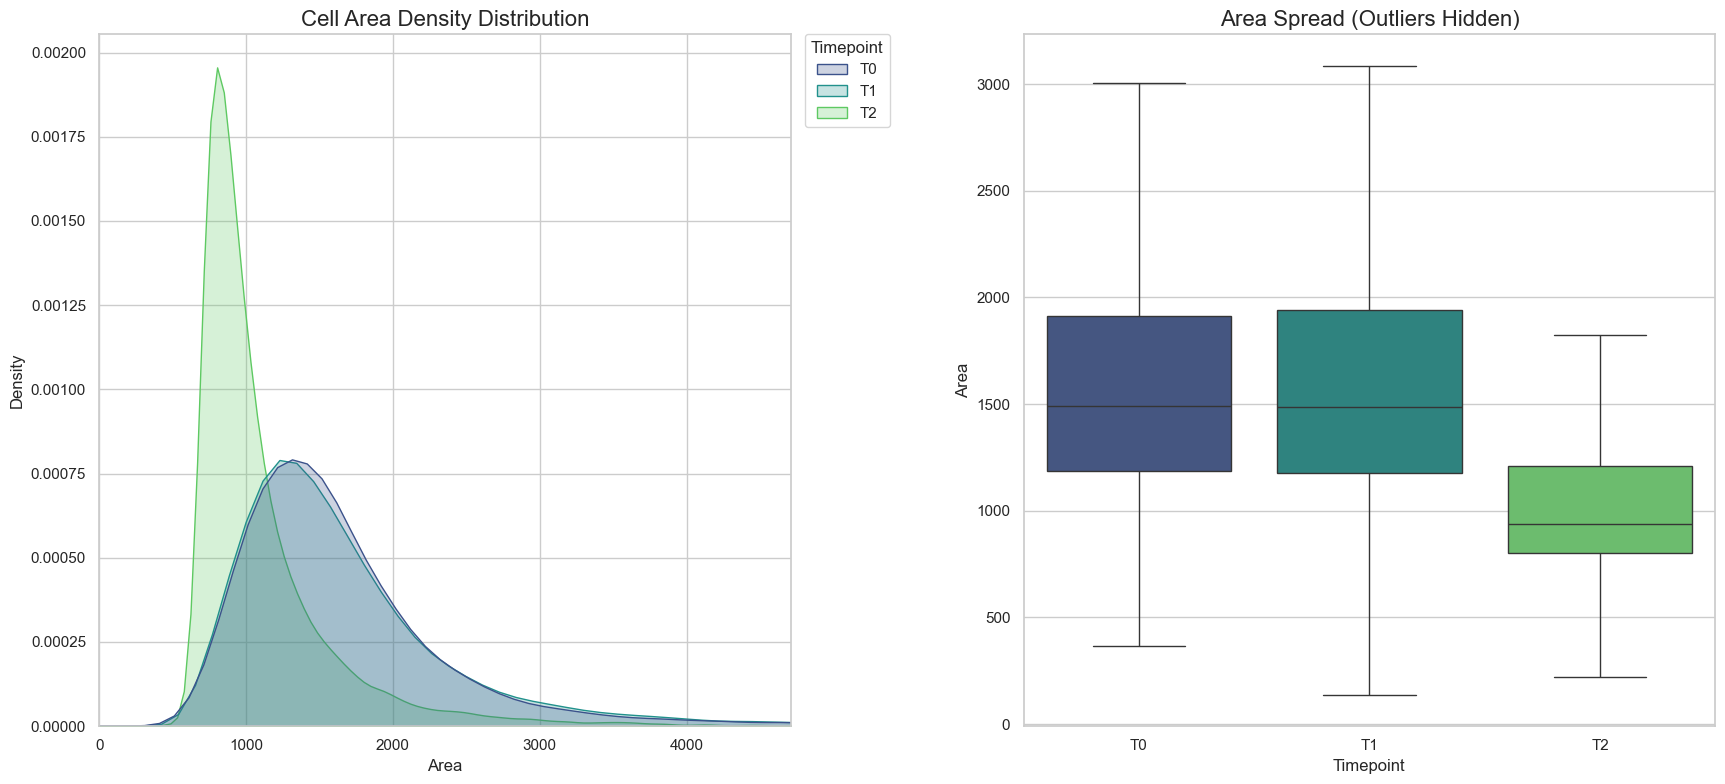

--- Statistics Summary ---
  Timepoint  Median_Area p_vs_T0_formatted p_T2vsT1_formatted
0        T0       1492.0               N/A                N/A
1        T1       1485.0            0.7485                N/A
2        T2        940.0          < 1e-300           < 1e-300


In [13]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# --- 1. SETUP & DATA CLEANING ---
FILE_PATH = r'E:\Thesis3april\overlay\all_individual_cells_areas.csv'
output_dir = r'E:\Thesis3april\statistics'
output_csv = os.path.join(output_dir, 'control_area_statistics_summary.csv')
os.makedirs(output_dir, exist_ok=True)

df = pd.read_csv(FILE_PATH)

# Filter for controls
df_ctrl = df[df['Treatment'].str.lower().isin(["no_sgrna", "nosgrna"])].copy()

# Extract Timepoint (T0, T1, T2) from Plate name
def extract_tp(plate_name):
    for tp in ['T0', 'T1', 'T2']:
        if tp in plate_name: return tp
    return None

df_ctrl['Timepoint'] = df_ctrl['Plate'].apply(extract_tp)
df_ctrl = df_ctrl.dropna(subset=['Timepoint'])

# --- 2. CALCULATE DESCRIPTIVE STATISTICS ---
def calculate_mad(series):
    return np.median(np.abs(series - series.median()))

summary = df_ctrl.groupby('Timepoint')['Area'].agg([
    ('Mean_Area', 'mean'),
    ('Median_Area', 'median'),
    ('Std_Dev', 'std'),
    ('Count', 'count')
]).reset_index()

mads = df_ctrl.groupby('Timepoint')['Area'].apply(calculate_mad).reset_index()
mads.columns = ['Timepoint', 'MAD']
summary = pd.merge(summary, mads, on='Timepoint')

# --- 3. CALCULATE P-VALUES ---
# Grab data for comparisons
t0_data = df_ctrl[df_ctrl['Timepoint'] == 'T0']['Area']
t1_data = df_ctrl[df_ctrl['Timepoint'] == 'T1']['Area']
t2_data = df_ctrl[df_ctrl['Timepoint'] == 'T2']['Area']

p_vs_t0 = {}
p_t2_vs_t1 = np.nan

for tp in summary['Timepoint'].unique():
    current_data = df_ctrl[df_ctrl['Timepoint'] == tp]['Area']
    
    # Comparison vs T0
    if tp == 'T0':
        p_vs_t0[tp] = np.nan
    else:
        _, p = mannwhitneyu(t0_data, current_data, alternative='two-sided')
        p_vs_t0[tp] = p
    
    # Specific T2 vs T1 Comparison
    if tp == 'T2' and not t1_data.empty:
        _, p_val = mannwhitneyu(t1_data, t2_data, alternative='two-sided')
        p_t2_vs_t1 = p_val

summary['p_value_vs_T0'] = summary['Timepoint'].map(p_vs_t0)
summary.loc[summary['Timepoint'] == 'T2', 'p_value_T2_vs_T1'] = p_t2_vs_t1

# --- 4. FORMATTING FOR OUTPUT ---
def format_p(p):
    if pd.isna(p): return "N/A"
    if p == 0 or p < 1e-300: return "< 1e-300"
    if p < 0.001: return f"{p:.2e}"
    return f"{p:.4f}"

summary['p_vs_T0_formatted'] = summary['p_value_vs_T0'].apply(format_p)
summary['p_T2vsT1_formatted'] = summary['p_value_T2_vs_T1'].apply(format_p)

# --- 5. PLOTTING DISTRIBUTIONS ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 8)) 

tp_order = sorted(df_ctrl['Timepoint'].unique())

# Plot A: KDE Distribution
kde_plot = sns.kdeplot(data=df_ctrl, x='Area', hue='Timepoint', hue_order=tp_order, 
            fill=True, palette='viridis', common_norm=False, ax=axes[0])
axes[0].set_title('Cell Area Density Distribution', fontsize=16)
axes[0].set_xlim(0, df_ctrl['Area'].quantile(0.99))
axes[0].set_box_aspect(1) # Square plotted region

# Move legend for KDE plot to the right
sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

# Plot B: Boxplot
sns.boxplot(data=df_ctrl, x='Timepoint', y='Area', order=tp_order, 
            palette='viridis', ax=axes[1], showfliers=False)
axes[1].set_title('Area Spread (Outliers Hidden)', fontsize=16)
axes[1].set_box_aspect(1) # Square plotted region

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'control_area_distributions_T2vsT1.png'), dpi=300)
plt.show()

# --- 6. SAVE OUTPUT ---
summary.to_csv(output_csv, index=False)

print("--- Statistics Summary ---")
print(summary[['Timepoint', 'Median_Area', 'p_vs_T0_formatted', 'p_T2vsT1_formatted']])

In [ ]:
#statistics on clusters

In [ ]:
#fatty acid

In [15]:
import pandas as pd
import os

# --- 1. INPUTS AND SETUP ---
# Update these paths to match your local setup
PROJECT_ROOT = r'E:\Thesis3april'
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "statistics", "evaluation_results")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Load your annotation data
anno_df = pd.read_excel(anno_path)

# --- 2. DEFINE YOUR DETECTIONS ---
# These are the genes you identified from the plot for the specific category
target_category = "biosynthesis of fatty acids"
my_detections = {'accA', 'accB', 'accC', 'accD', 'fabD', 'fabF', 'fabG', 'plsC', 'plsX'}

# --- 3. CALCULATION LOGIC ---
# Get Ground Truth from the Excel file based on your plotting logic
# We look at both Annotation 4 and 3
ground_truth_mask = (
    (anno_df['SubtiWiki Annotation 4'] == target_category) | 
    ((anno_df['SubtiWiki Annotation 4'].isna()) & (anno_df['SubtiWiki Annotation 3'] == target_category))
)
ground_truth_genes = set(anno_df.loc[ground_truth_mask, 'Treatment'].unique())
all_genes_in_dataset = set(anno_df['Treatment'].unique())

# Core Metrics
tp_genes = my_detections.intersection(ground_truth_genes)
fp_genes = my_detections - ground_truth_genes
fn_genes = ground_truth_genes - my_detections

tp = len(tp_genes)
fp = len(fp_genes)
fn = len(fn_genes)
tn = len(all_genes_in_dataset - (ground_truth_genes | my_detections))

# Math for Metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + fp + fn + tn)
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# --- 4. CREATE SUMMARY AND SAVE ---
summary_data = {
    "Metric": ["Category", "True Positives", "False Positives", "False Negatives", "True Negatives", "Precision", "Recall", "Accuracy", "F1-Score"],
    "Value": [target_category, tp, fp, fn, tn, f"{precision:.4f}", f"{recall:.4f}", f"{accuracy:.4f}", f"{f1:.4f}"],
    "Genes_Involved": ["-", ", ".join(tp_genes), ", ".join(fp_genes), ", ".join(fn_genes), "Remaining dataset", "-", "-", "-", "-"]
}

summary_df = pd.DataFrame(summary_data)
csv_output_path = os.path.join(OUTPUT_DIR, "FattyAcidgene_detection_summary.csv")
summary_df.to_csv(csv_output_path, index=False)

print(f"Evaluation complete.")
print(f"Summary saved to: {csv_output_path}")

# Quick print to console for immediate checking
print("\n--- Quick Stats ---")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")

Evaluation complete.
Summary saved to: E:\Thesis3april\statistics\evaluation_results\FattyAcidgene_detection_summary.csv

--- Quick Stats ---
Precision: 100.00%
Recall:    69.23%


In [ ]:
#ribosomal

In [ ]:
import pandas as pd
import os

# --- 1. INPUTS AND SETUP ---
# Update these paths to match your local setup
PROJECT_ROOT = r'E:\Thesis3april'
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "statistics", "evaluation_results")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Load your annotation data
anno_df = pd.read_excel(anno_path)

# --- 2. DEFINE YOUR DETECTIONS ---
# These are the genes you identified from the plot for the specific category
target_category = "ribosomal proteins"
my_detections = {"rpsQ", "secY", "rpsNA", "rplC", "rpsJ", "rpsE", 
    "rplF", "rpsH", "rpsI", "rplM", "rplX", "rplR105", 
    "rpoC", "rpsK", "rplE", "sigA", "rpsR", "dnaG"}

# --- 3. CALCULATION LOGIC ---
# Get Ground Truth from the Excel file based on your plotting logic
# We look at both Annotation 4 and 3
ground_truth_mask = (
    (anno_df['SubtiWiki Annotation 4'] == target_category) | 
    ((anno_df['SubtiWiki Annotation 4'].isna()) & (anno_df['SubtiWiki Annotation 3'] == target_category))
)
ground_truth_genes = set(anno_df.loc[ground_truth_mask, 'Treatment'].unique())
all_genes_in_dataset = set(anno_df['Treatment'].unique())

# Core Metrics
tp_genes = my_detections.intersection(ground_truth_genes)
fp_genes = my_detections - ground_truth_genes
fn_genes = ground_truth_genes - my_detections

tp = len(tp_genes)
fp = len(fp_genes)
fn = len(fn_genes)
tn = len(all_genes_in_dataset - (ground_truth_genes | my_detections))

# Math for Metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + fp + fn + tn)
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# --- 4. CREATE SUMMARY AND SAVE ---
summary_data = {
    "Metric": ["Category", "True Positives", "False Positives", "False Negatives", "True Negatives", "Precision", "Recall", "Accuracy", "F1-Score"],
    "Value": [target_category, tp, fp, fn, tn, f"{precision:.4f}", f"{recall:.4f}", f"{accuracy:.4f}", f"{f1:.4f}"],
    "Genes_Involved": ["-", ", ".join(tp_genes), ", ".join(fp_genes), ", ".join(fn_genes), "Remaining dataset", "-", "-", "-", "-"]
}

summary_df = pd.DataFrame(summary_data)
csv_output_path = os.path.join(OUTPUT_DIR, "Ribosomal_detection_summary.csv")


summary_df.to_csv(csv_output_path, index=False)

print(f"Evaluation complete.")
print(f"Summary saved to: {csv_output_path}")

# Quick print to console for immediate checking
print("\n--- Quick Stats ---")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")

Evaluation complete.
Summary saved to: E:\Thesis3april\statistics\evaluation_results\Ribosomal_detection_summary.csv

--- Quick Stats ---
Precision: 77.78%
Recall:    37.84%


In [4]:
#"dnaE", "dnaA", "dnaC", "dnaN", "dnaX", "holB", "holA"

import pandas as pd
import os

# --- 1. INPUTS AND SETUP ---
# Update these paths to match your local setup
PROJECT_ROOT = r'E:\Thesis3april'
anno_path = os.path.join(PROJECT_ROOT, "files", "Pathway_annotation.xlsx")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "statistics", "evaluation_results")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Load your annotation data
anno_df = pd.read_excel(anno_path)

# --- 2. DEFINE YOUR DETECTIONS ---
# These are the genes you identified from the plot for the specific category
target_category = "DNA condensation/ segregation"
my_detections = {"dnaE", "dnaA", "dnaC", "dnaN", "dnaX", "holB", "holA"}

# --- 3. CALCULATION LOGIC ---
# Get Ground Truth from the Excel file based on your plotting logic
# We look at both Annotation 4 and 3
ground_truth_mask = (
    (anno_df['SubtiWiki Annotation 4'] == target_category) | 
    ((anno_df['SubtiWiki Annotation 4'].isna()) & (anno_df['SubtiWiki Annotation 3'] == target_category))
)
ground_truth_genes = set(anno_df.loc[ground_truth_mask, 'Treatment'].unique())
all_genes_in_dataset = set(anno_df['Treatment'].unique())

# Core Metrics
tp_genes = my_detections.intersection(ground_truth_genes)
fp_genes = my_detections - ground_truth_genes
fn_genes = ground_truth_genes - my_detections

tp = len(tp_genes)
fp = len(fp_genes)
fn = len(fn_genes)
tn = len(all_genes_in_dataset - (ground_truth_genes | my_detections))

# Math for Metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + fp + fn + tn)
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# --- 4. CREATE SUMMARY AND SAVE ---
summary_data = {
    "Metric": ["Category", "True Positives", "False Positives", "False Negatives", "True Negatives", "Precision", "Recall", "Accuracy", "F1-Score"],
    "Value": [target_category, tp, fp, fn, tn, f"{precision:.4f}", f"{recall:.4f}", f"{accuracy:.4f}", f"{f1:.4f}"],
    "Genes_Involved": ["-", ", ".join(tp_genes), ", ".join(fp_genes), ", ".join(fn_genes), "Remaining dataset", "-", "-", "-", "-"]
}

summary_df = pd.DataFrame(summary_data)
csv_output_path = os.path.join(OUTPUT_DIR, "DNA condensation_segregation_detection_summary.csv")
os.makedirs(csv_output_path, exist_ok=True)


print(f"Evaluation complete.")
print(f"Summary saved to: {csv_output_path}")

# Quick print to console for immediate checking
print("\n--- Quick Stats ---")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")

Evaluation complete.
Summary saved to: E:\Thesis3april\statistics\evaluation_results\DNA condensation_segregation_detection_summary.csv

--- Quick Stats ---
Precision: 0.00%
Recall:    0.00%
